Install library

In [13]:
!pip install -U google-api-python-client pandas numpy tqdm scikit-learn matplotlib seaborn wordcloud transformers datasets torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 117.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 105.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 140.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 137.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 112.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [9]:
!pip3 uninstall torchvision

Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Would remove:
    /usr/local/lib/python3.12/dist-packages/torchvision-0.25.0+cu128.dist-info/*
    /usr/local/lib/python3.12/dist-packages/torchvision.libs/libcudart.e8e8b82a.so.12
    /usr/local/lib/python3.12/dist-packages/torchvision.libs/libjpeg.4af9affd.so.8
    /usr/local/lib/python3.12/dist-packages/torchvision.libs/libnvjpeg.8dd2b5e6.so.12
    /usr/local/lib/python3.12/dist-packages/torchvision.libs/libpng16.c2edc9e1.so.16
    /usr/local/lib/python3.12/dist-packages/torchvision.libs/libsharpyuv.994c9d2c.so.0
    /usr/local/lib/python3.12/dist-packages/torchvision.libs/libwebp.87a45f40.so.7
    /usr/local/lib/python3.12/dist-packages/torchvision.libs/libz.03209371.so.1
    /usr/local/lib/python3.12/dist-packages/torchvision/*
Proceed (Y/n)? Y
  Successfully uninstalled torchvision-0.25.0+cu128


In [1]:
import torch
print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())

try:
    import torchvision
    print("torchvision:", torchvision.__version__)
except Exception as e:
    print("torchvision import error:", e)

torch: 2.11.0+cu130
torch cuda: 13.0
cuda available: True
torchvision import error: No module named 'torchvision'


In [2]:
import transformers
print("transformers:", transformers.__version__)

from transformers import TrainingArguments, AutoTokenizer, AutoModelForSequenceClassification
print("Transformers core import OK")

transformers: 5.6.2
Transformers core import OK


Mount Google Drive

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


Script

In [ ]:
%%writefile project_bop_sentiment_dual_comparation_indobert.py


# ============================================================
# Project: Sentiment Analysis Board of Peace (YouTube Comments)
# Dual Method:
#   (1) InSet Lexicon -> IndoBERT fine-tuning
#   (2) SmSA Transfer Learning -> IndoBERT fine-tuning
#
# Outputs:
#   - CSV backups on Google Drive at each stage
#   - Accuracy/F1 + Confusion Matrix
#   - Wordcloud per label
#   - Weekly sentiment trend (2025 - now)
#   - Topic modeling (LDA) per label
# ============================================================

import os
import re
import json
import time
import math
import html
import shutil
import random
import requests
import datetime as dt
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.utils import class_weight

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    pipeline,
)

# YouTube API
from googleapiclient.discovery import build
from googleapiclient.errors import HttpError


# ============================================================
# 1) CONFIG
# ============================================================

@dataclass
class Config:
    # --- YouTube ---
    API_KEY: str = ""
    RELEVANCE_LANGUAGE: str = "id"
    MAX_VIDEOS_PER_KEYWORD: int = 30           # agar lebih terkendali
    MAX_COMMENTS_PER_KEYWORD: int = 2000       # target per keyword (seperti skrip Anda)
    MAX_COMMENTS_PER_VIDEO: Optional[int] = None  # None = ambil sebanyak bisa (dibatasi quota)

    # --- Time filter ---
    START_DATE: str = "2025-01-01"  # hanya pakai komentar >= tanggal ini

    # --- IndoBERT ---
    BASE_MODEL: str = "indobenchmark/indobert-base-p1"
    MAX_LEN: int = 128
    NUM_LABELS: int = 3

    # Label order
    # 0=negatif, 1=netral, 2=positif
    LABEL2ID: Dict[str, int] = None
    ID2LABEL: Dict[int, str] = None

    # --- Training ---
    SEED: int = 42
    TEST_SIZE: float = 0.15
    VAL_SIZE_FROM_TRAIN: float = 0.10  # 10% dari train untuk val internal
    EPOCHS: int = 3
    BATCH_TRAIN: int = 16
    BATCH_EVAL: int = 16
    LR: float = 2e-5
    WEIGHT_DECAY: float = 0.01

    # --- Output on Drive ---
    DRIVE_MOUNT: str = "/content/drive"
    DRIVE_BASE_DIR: str = "/content/drive/MyDrive/Colab Notebooks/Board of Peace/"
    # subdirs
    DATA_DIR: str = "data"
    MODELS_DIR: str = "models"
    REPORTS_DIR: str = "reports"

    # --- Visualization ---
    WEEKLY_FREQ: str = "W"  # weekly

    def __post_init__(self):
        if self.LABEL2ID is None:
            self.LABEL2ID = {"negatif": 0, "netral": 1, "positif": 2}
        if self.ID2LABEL is None:
            self.ID2LABEL = {v: k for k, v in self.LABEL2ID.items()}

    USE_EXISTING_DATASET: bool = True
    EXISTING_DATASET_PATH: str = "/content/drive/MyDrive/Colab Notebooks/Board of Peace/youtube_comments_raw.csv"

CFG = Config()


# ============================================================
# 2) UTILITIES (backup, seed, directories)
# ============================================================

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)


def drive_paths(cfg: Config) -> Dict[str, str]:
    base = cfg.DRIVE_BASE_DIR
    paths = {
        "base": base,
        "data": os.path.join(base, cfg.DATA_DIR),
        "models": os.path.join(base, cfg.MODELS_DIR),
        "reports": os.path.join(base, cfg.REPORTS_DIR),
    }
    for p in paths.values():
        ensure_dir(p)
    return paths


def save_csv_backup(df: pd.DataFrame, path: str):
    ensure_dir(os.path.dirname(path))
    df.to_csv(path, index=False)
    print(f"[BACKUP] CSV saved: {path} (rows={len(df)})")


def save_json_backup(obj: dict, path: str):
    ensure_dir(os.path.dirname(path))
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
    print(f"[BACKUP] JSON saved: {path}")


def load_if_exists_csv(path: str) -> Optional[pd.DataFrame]:
    if os.path.exists(path):
        print(f"[LOAD] Found existing file: {path}")
        return pd.read_csv(path)
    return None

def load_existing_dataset_from_drive(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Existing dataset not found at: {path}")
    df = pd.read_csv(path)
    print(f"[LOAD] Existing dataset loaded from Drive: {path} (rows={len(df)}, cols={list(df.columns)})")
    return df


def now_stamp() -> str:
    return dt.datetime.now().strftime("%Y%m%d_%H%M%S")


# ============================================================
# 3) MOUNT DRIVE (Colab)
# ============================================================

def mount_drive(cfg: Config):
    # Only for Colab
    try:
        from google.colab import drive
        drive.mount(cfg.DRIVE_MOUNT)
    except Exception as e:
        print("[INFO] Not running in Colab or Drive mount failed:", e)


# ============================================================
# 4) SCRAPING YOUTUBE
# ============================================================

def build_youtube_client(api_key: str):
    return build("youtube", "v3", developerKey=api_key)


def search_videos(youtube, query: str, max_videos: int = 30, relevance_language: str = "id") -> List[str]:
    """
    Search videos by keyword with pagination.
    """
    video_ids = []
    next_page = None

    while True:
        req = youtube.search().list(
            q=query,
            part="id",
            type="video",
            maxResults=50,  # max per request
            relevanceLanguage=relevance_language,
            pageToken=next_page,
        )
        resp = req.execute()

        items = resp.get("items", [])
        for it in items:
            vid = it.get("id", {}).get("videoId")
            if vid:
                video_ids.append(vid)
            if len(video_ids) >= max_videos:
                return list(dict.fromkeys(video_ids))  # unique preserve order

        next_page = resp.get("nextPageToken")
        if not next_page:
            break

    return list(dict.fromkeys(video_ids))


def fetch_comments_for_video(youtube, video_id: str, max_comments: Optional[int] = None) -> List[dict]:
    """
    Fetch top-level comments for a given video.
    """
    out = []
    next_page = None
    fetched = 0

    while True:
        try:
            req = youtube.commentThreads().list(
                part="snippet",
                videoId=video_id,
                maxResults=100,
                pageToken=next_page,
                textFormat="plainText"  # lebih bersih daripada textDisplay
            )
            resp = req.execute()
        except HttpError as e:
            # komentar dimatikan / limit / dll
            # log ringkas
            print(f"[WARN] HttpError on video={video_id}: {e}")
            break

        for item in resp.get("items", []):
            top = item["snippet"]["topLevelComment"]
            comment_id = top.get("id")
            snip = top["snippet"]
            out.append({
                "comment_id": comment_id,
                "video_id": video_id,
                "published_at": snip.get("publishedAt"),
                "text": snip.get("textDisplay") or snip.get("textOriginal") or "",
                "like_count": snip.get("likeCount", 0),
            })
            fetched += 1
            if max_comments and fetched >= max_comments:
                return out

        next_page = resp.get("nextPageToken")
        if not next_page:
            break

    return out


def scrape_comments_by_keywords(
    youtube,
    keywords: List[str],
    max_videos_per_kw: int,
    max_comments_per_kw: int,
    relevance_language: str = "id",
    max_comments_per_video: Optional[int] = None
) -> pd.DataFrame:
    """
    Scrape comments for each keyword.
    """
    rows = []

    for kw in keywords:
        print(f"\n=== Scraping keyword: {kw} ===")
        try:
            video_ids = search_videos(youtube, kw, max_videos=max_videos_per_kw, relevance_language=relevance_language)
        except HttpError as e:
            print(f"[ERROR] Search failed for kw={kw}: {e}")
            continue

        kw_count = 0
        for vid in tqdm(video_ids, desc=f"Videos for '{kw}'"):
            if kw_count >= max_comments_per_kw:
                break

            # sisa limit untuk keyword ini
            remaining = max_comments_per_kw - kw_count
            per_video_limit = max_comments_per_video
            if per_video_limit is None:
                per_video_limit = None
            else:
                per_video_limit = min(per_video_limit, remaining)

            comments = fetch_comments_for_video(youtube, vid, max_comments=per_video_limit)
            for c in comments:
                c["keyword"] = kw
                rows.append(c)

            kw_count += len(comments)

        print(f"[INFO] Collected comments for '{kw}': {kw_count}")

    df = pd.DataFrame(rows)
    return df


# ============================================================
# 5) FILTER DATE (>= 2025-01-01)
# ============================================================

def filter_by_date(df: pd.DataFrame, start_date: str) -> pd.DataFrame:
    if df.empty:
        return df
    df = df.copy()
    df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce", utc=True)
    start = pd.to_datetime(start_date, utc=True)
    df = df[df["published_at"] >= start]
    df = df.dropna(subset=["published_at"])
    return df


# ============================================================
# 6) CLEANING / NORMALIZATION
# ============================================================

NORM_MAP = {
    "yg": "yang", "jg": "juga", "biar": "agar", "nggak": "tidak",
    "gak": "tidak", "gk": "tidak", "ga": "tidak", "tdk": "tidak",
    "jgn": "jangan", "buat": "untuk", "utk": "untuk", "bgt": "banget",
    "dgn": "dengan", "krn": "karena", "pdhl": "padahal", "jd": "jadi",
    "sdh": "sudah", "udah": "sudah", "blm": "belum", "blom": "belum",
    "byk": "banyak", "tp": "tapi", "trs": "terus", "hrs": "harus",
    "klo": "kalau", "kl": "kalau", "kalo": "kalau", "org": "orang",
    "spt": "seperti", "lg": "lagi", "knp": "kenapa", "skrg": "sekarang",
    "dmn": "dimana", "gmn": "bagaimana", "gimana": "bagaimana",
    "emang": "memang", "gw": "saya", "gue": "saya", "lu": "kamu",
    "aq": "saya", "sy": "saya", "cuma": "hanya", "cuman": "hanya",
    "doang": "saja", "aj": "saja", "aja": "saja",
    "wkwk": "tertawa", "haha": "tertawa", "lol": "tertawa",
    "bop": "board of peace",
    "pbb": "perserikatan bangsa bangsa",
    "us": "amerika serikat",
}

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    t = html.unescape(text)
    t = re.sub(r"<[^>]+>", " ", t)
    t = re.sub(r"http\S+|www\S+|https\S+", " ", t)
    t = re.sub(r"@\w+", " ", t)
    t = re.sub(r"#\w+", " ", t)
    t = re.sub(r"\d+", " ", t)

    # Keep letters/numbers/space only (emoji removed; bisa Anda ubah kalau ingin)
    t = re.sub(r"[^\w\s]", " ", t)
    t = t.lower()

    # Normalize token-based
    tokens = [tok for tok in t.split() if tok.strip()]
    tokens = [NORM_MAP.get(tok, tok) for tok in tokens]
    t = " ".join(tokens)
    t = re.sub(r"\s+", " ", t).strip()
    return t


def apply_cleaning(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["text_cleaned"] = df["text"].apply(clean_text)
    df = df[df["text_cleaned"].str.strip().astype(bool)]
    return df


# ============================================================
# 7) LEXICON LABELING (InSet)
# ============================================================

def load_inset_lexicon() -> Dict[str, int]:
    url_pos = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
    url_neg = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

    pos = pd.read_csv(url_pos, sep="\t")
    neg = pd.read_csv(url_neg, sep="\t")

    lex = {}
    for _, r in pos.iterrows():
        lex[str(r["word"])] = int(r["weight"])
    for _, r in neg.iterrows():
        lex[str(r["word"])] = int(r["weight"])
    return lex


def lexicon_score(text_cleaned: str, lex: Dict[str, int]) -> int:
    if not isinstance(text_cleaned, str) or not text_cleaned.strip():
        return 0
    return int(sum(lex.get(w, 0) for w in text_cleaned.split()))


def lexicon_label(score: int) -> str:
    if score > 0:
        return "positif"
    if score < 0:
        return "negatif"
    return "netral"


def label_with_lexicon(df: pd.DataFrame, lex: Dict[str, int]) -> pd.DataFrame:
    df = df.copy()
    df["lexicon_score"] = df["text_cleaned"].apply(lambda x: lexicon_score(x, lex))
    df["label_lexicon"] = df["lexicon_score"].apply(lexicon_label)
    df["label_lexicon_id"] = df["label_lexicon"].map(CFG.LABEL2ID)
    return df


# ============================================================
# 8) TRAINING HELPERS (IndoBERT)
# ============================================================

def split_train_val_test_for_df(
    df: pd.DataFrame,
    label_id_col: str,
    text_col: str = "text_cleaned",
    test_size: float = 0.15,
    val_size_from_train: float = 0.10,
    seed: int = 42
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Split df into train/val/test with stratification.
    """
    df = df.dropna(subset=[text_col, label_id_col]).copy()

    train_val, test = train_test_split(
        df,
        test_size=test_size,
        random_state=seed,
        stratify=df[label_id_col]
    )

    # val_size_from_train is fraction of train_val
    train, val = train_test_split(
        train_val,
        test_size=val_size_from_train,
        random_state=seed,
        stratify=train_val[label_id_col]
    )

    return train, val, test


def build_trainer(
    model_name_or_dir: str,
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    text_col: str,
    label_id_col: str,
    out_dir: str,
    cfg: Config
):
    tokenizer = AutoTokenizer.from_pretrained(model_name_or_dir)

    def tokenize_batch(examples):
        return tokenizer(
            examples[text_col],
            truncation=True,
            padding=False,
            max_length=cfg.MAX_LEN,
        )

    # Convert pandas -> HF datasets (without importing datasets to keep code short)
    from datasets import Dataset
    train_ds = Dataset.from_pandas(train_df[[text_col, label_id_col]].rename(columns={label_id_col: "labels"}))
    val_ds = Dataset.from_pandas(val_df[[text_col, label_id_col]].rename(columns={label_id_col: "labels"}))

    train_ds = train_ds.map(tokenize_batch, batched=True)
    val_ds = val_ds.map(tokenize_batch, batched=True)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name_or_dir,
        num_labels=cfg.NUM_LABELS,
        ignore_mismatched_sizes=True
    )
    model.config.label2id = cfg.LABEL2ID
    model.config.id2label = cfg.ID2LABEL

    # Class weights for imbalance
    y_train = train_df[label_id_col].values
    weights = class_weight.compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train),
        y=y_train
    )
    class_weights_tensor = torch.tensor(weights, dtype=torch.float)
    if torch.cuda.is_available():
        class_weights_tensor = class_weights_tensor.to("cuda")

    # Custom Trainer for weighted CE loss
    class WeightedLossTrainer(Trainer):
        def __init__(self, *args, class_weights=None, **kwargs):
            super().__init__(*args, **kwargs)
            self.class_weights = class_weights

        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels")
            outputs = model(**inputs)
            logits = outputs.logits
            loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)
            loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
            return (loss, outputs) if return_outputs else loss

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)
        acc = accuracy_score(labels, preds)
        return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

    args = TrainingArguments(
        output_dir=out_dir,
        learning_rate=cfg.LR,
        per_device_train_batch_size=cfg.BATCH_TRAIN,
        per_device_eval_batch_size=cfg.BATCH_EVAL,
        num_train_epochs=cfg.EPOCHS,
        weight_decay=cfg.WEIGHT_DECAY,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        logging_steps=50,
        report_to="none",
        seed=cfg.SEED,
    )

    trainer = WeightedLossTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        class_weights=class_weights_tensor
    )

    return trainer, model, tokenizer


def predict_labels_with_pipeline(
    df: pd.DataFrame,
    model_dir: str,
    text_col: str = "text_cleaned",
    out_label_col: str = "pred_label",
    out_score_col: str = "pred_score"
) -> pd.DataFrame:
    df = df.copy()
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir)

    device_id = 0 if torch.cuda.is_available() else -1
    pipe = pipeline("text-classification", model=model, tokenizer=tokenizer, device=device_id)

    labels = []
    scores = []

    # batch manual (pipeline batching bisa bervariasi)
    for txt in tqdm(df[text_col].astype(str).tolist(), desc=f"Predicting with {os.path.basename(model_dir)}"):
        if not txt.strip():
            labels.append("netral")
            scores.append(0.0)
            continue
        res = pipe(txt[:512])[0]
        # res['label'] should already be 'negatif/netral/positif' if config saved correctly,
        # but to be safe we map LABEL_0 etc.
        raw_label = res["label"]
        score = float(res["score"])
        mapping_fallback = {"LABEL_0": "negatif", "LABEL_1": "netral", "LABEL_2": "positif"}
        final_label = mapping_fallback.get(raw_label, raw_label.lower())
        labels.append(final_label)
        scores.append(score)

    df[out_label_col] = labels
    df[out_score_col] = scores
    return df


# ============================================================
# 9) EVALUATION (Confusion Matrix, Report)
# ============================================================

def evaluate_predictions(y_true: List[int], y_pred: List[int], cfg: Config) -> Dict[str, float]:
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    return {"accuracy": float(acc), "precision": float(precision), "recall": float(recall), "f1": float(f1)}


def plot_confusion(y_true: List[int], y_pred: List[int], title: str, save_path: Optional[str] = None, cfg: Config = CFG):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
    names = ["Negatif", "Netral", "Positif"]

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=names, yticklabels=names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    if save_path:
        ensure_dir(os.path.dirname(save_path))
        plt.savefig(save_path, dpi=200)
        print(f"[REPORT] Confusion matrix saved: {save_path}")
    plt.show()


# ============================================================
# 10) VISUALIZATION: Wordcloud / Trend Weekly / LDA Topics
# ============================================================

def load_stopwords_id() -> set:
    url = "https://raw.githubusercontent.com/masdevid/ID-Stopwords/master/id.stopwords.02.01.2016.txt"
    txt = requests.get(url, timeout=60).text
    sw = set([w.strip() for w in txt.splitlines() if w.strip()])
    custom = {"yg", "aja", "kalo", "nya", "sih", "mah", "deh", "dong", "di", "ke", "dari",
              "bop", "board", "peace", "indonesia"}
    return sw.union(custom)


def wordcloud_per_label(df: pd.DataFrame, label_col: str, text_col: str, stopwords: set, out_dir: str, prefix: str):
    labels = ["negatif", "netral", "positif"]
    for lab in labels:
        sub = df[df[label_col] == lab]
        if sub.empty:
            print(f"[WARN] No data for wordcloud label={lab} ({prefix})")
            continue
        text = " ".join(sub[text_col].astype(str).tolist()).strip()
        if not text:
            continue

        wc = WordCloud(width=900, height=450, background_color="white",
                       stopwords=stopwords, max_words=120, colormap="viridis").generate(text)

        plt.figure(figsize=(12, 6))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"Wordcloud - {prefix} - {lab}", fontsize=14)
        plt.tight_layout()

        path = os.path.join(out_dir, f"{prefix}_wordcloud_{lab}.png")
        ensure_dir(out_dir)
        plt.savefig(path, dpi=200)
        print(f"[REPORT] Wordcloud saved: {path}")
        plt.show()


def weekly_trend_plot(df: pd.DataFrame, label_col: str, date_col: str, out_dir: str, prefix: str, start_date="2025-01-01"):
    if df.empty:
        return
    d = df.copy()
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce", utc=True)
    d = d.dropna(subset=[date_col])
    d = d[d[date_col] >= pd.to_datetime(start_date, utc=True)]
    if d.empty:
        print(f"[WARN] No data after {start_date} for trend ({prefix})")
        return

    # weekly bucket
    d["week"] = d[date_col].dt.to_period("W").apply(lambda r: r.start_time)

    trend = d.groupby(["week", label_col]).size().reset_index(name="count")

    plt.figure(figsize=(13, 6))
    sns.lineplot(data=trend, x="week", y="count", hue=label_col, marker="o")
    plt.title(f"Weekly Sentiment Trend (2025 - Now) - {prefix}")
    plt.xlabel("Week")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()

    path = os.path.join(out_dir, f"{prefix}_weekly_trend.png")
    ensure_dir(out_dir)
    plt.savefig(path, dpi=200)
    print(f"[REPORT] Trend plot saved: {path}")
    plt.show()


def lda_topics_per_label(
    df: pd.DataFrame,
    label_col: str,
    text_col: str,
    stopwords: set,
    out_dir: str,
    prefix: str,
    n_topics: int = 3,
    n_top_words: int = 10
):
    """
    LDA per label: fit LDA on each sentiment subset, print & save topics.
    """
    ensure_dir(out_dir)
    labels = ["negatif", "netral", "positif"]
    results = {}

    for lab in labels:
        sub = df[df[label_col] == lab]
        if len(sub) < 50:
            print(f"[WARN] Too few rows for LDA label={lab} ({prefix}). rows={len(sub)}")
            continue

        vectorizer = CountVectorizer(
            stop_words=list(stopwords),
            max_df=0.9,
            min_df=5
        )
        X = vectorizer.fit_transform(sub[text_col].astype(str))
        if X.shape[1] < 20:
            print(f"[WARN] Too few vocabulary terms for LDA label={lab} ({prefix}). vocab={X.shape[1]}")
            continue

        lda = LatentDirichletAllocation(n_components=n_topics, random_state=CFG.SEED, max_iter=10)
        lda.fit(X)

        feature_names = vectorizer.get_feature_names_out()
        topics = []
        for t_idx, comp in enumerate(lda.components_):
            top_idx = comp.argsort()[:-n_top_words-1:-1]
            top_words = [feature_names[i] for i in top_idx]
            topics.append(top_words)

        results[lab] = topics

    # Save to txt/json for report
    txt_path = os.path.join(out_dir, f"{prefix}_lda_topics.txt")
    with open(txt_path, "w", encoding="utf-8") as f:
        for lab, topics in results.items():
            f.write(f"== {prefix} | {lab} ==\n")
            for i, words in enumerate(topics, start=1):
                f.write(f"Topic {i}: {', '.join(words)}\n")
            f.write("\n")

    print(f"[REPORT] LDA topics saved: {txt_path}")
    return results


# ============================================================
# 11) SmSA Dataset Loader (GitHub)
# ============================================================

def load_smsa_from_github():
    train_url = "https://raw.githubusercontent.com/indobenchmark/indonlu/master/dataset/smsa_doc-sentiment-prosa/train_preprocess.tsv"
    valid_url = "https://raw.githubusercontent.com/indobenchmark/indonlu/master/dataset/smsa_doc-sentiment-prosa/valid_preprocess.tsv"
    test_url  = "https://raw.githubusercontent.com/indobenchmark/indonlu/master/dataset/smsa_doc-sentiment-prosa/test_preprocess.tsv"

    df_train = pd.read_csv(train_url, sep="\t", header=None, names=["text", "label"])
    df_valid = pd.read_csv(valid_url, sep="\t", header=None, names=["text", "label"])
    df_test  = pd.read_csv(test_url,  sep="\t", header=None, names=["text", "label"])

    # SmSA label: positive/neutral/negative
    # Kita map ke: negatif=0, netral=1, positif=2 (agar konsisten)
    mapping = {"negative": 0, "neutral": 1, "positive": 2}
    df_train["labels"] = df_train["label"].map(mapping)
    df_valid["labels"] = df_valid["label"].map(mapping)
    df_test["labels"]  = df_test["label"].map(mapping)

    return df_train, df_valid, df_test


def train_smsa_indobert(cfg: Config, out_model_dir: str):
    df_train, df_valid, df_test = load_smsa_from_github()

    tokenizer = AutoTokenizer.from_pretrained(cfg.BASE_MODEL)

    from datasets import Dataset
    train_ds = Dataset.from_pandas(df_train[["text", "labels"]])
    valid_ds = Dataset.from_pandas(df_valid[["text", "labels"]])
    test_ds  = Dataset.from_pandas(df_test[["text", "labels"]])

    def tok(examples):
        return tokenizer(examples["text"], truncation=True, max_length=cfg.MAX_LEN)

    train_ds = train_ds.map(tok, batched=True)
    valid_ds = valid_ds.map(tok, batched=True)
    test_ds  = test_ds.map(tok, batched=True)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(
        cfg.BASE_MODEL,
        num_labels=cfg.NUM_LABELS,
        ignore_mismatched_sizes=True
    )
    model.config.label2id = cfg.LABEL2ID
    model.config.id2label = cfg.ID2LABEL

    # Class weights based on SmSA train distribution
    y_train = df_train["labels"].values
    weights = class_weight.compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
    class_weights_tensor = torch.tensor(weights, dtype=torch.float)
    if torch.cuda.is_available():
        class_weights_tensor = class_weights_tensor.to("cuda")

    class WeightedLossTrainer(Trainer):
        def __init__(self, *args, class_weights=None, **kwargs):
            super().__init__(*args, **kwargs)
            self.class_weights = class_weights

        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels")
            outputs = model(**inputs)
            logits = outputs.logits
            loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)
            loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
            return (loss, outputs) if return_outputs else loss

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)
        acc = accuracy_score(labels, preds)
        return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

    args = TrainingArguments(
        output_dir=out_model_dir,
        learning_rate=cfg.LR,
        per_device_train_batch_size=cfg.BATCH_TRAIN,
        per_device_eval_batch_size=cfg.BATCH_EVAL,
        num_train_epochs=cfg.EPOCHS,
        weight_decay=cfg.WEIGHT_DECAY,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        logging_steps=50,
        report_to="none",
        seed=cfg.SEED,
    )

    trainer = WeightedLossTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=valid_ds,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        class_weights=class_weights_tensor
    )

    trainer.train()

    # Evaluate on test
    pred = trainer.predict(test_ds)
    y_true = pred.label_ids
    y_pred = np.argmax(pred.predictions, axis=-1)

    metrics = evaluate_predictions(y_true, y_pred, cfg)
    print("[SmSA TEST] metrics:", metrics)
    print(classification_report(y_true, y_pred, target_names=["Negatif", "Netral", "Positif"], zero_division=0))

    # Save model + tokenizer
    ensure_dir(out_model_dir)
    trainer.save_model(out_model_dir)
    tokenizer.save_pretrained(out_model_dir)
    print(f"[MODEL SAVED] SmSA IndoBERT saved to: {out_model_dir}")

    return out_model_dir, metrics, (y_true, y_pred)


# ============================================================
# 12) MAIN PIPELINE
# ============================================================

def main():
    set_seed(CFG.SEED)
    mount_drive(CFG)
    paths = drive_paths(CFG)

    # ---------------------------
    # Step A: Define keywords
    # ---------------------------
    keywords = [
        "Board of Peace Indonesia",
        "Dewan Perdamaian",
        "Indonesia gabung dengan Board of Peace",
        "Indonesia penengah konflik AS Iran",
        "Dampak perang Amerika Iran Indonesia",
        "Peran Indonesia konflik Timur Tengah",
    ]

    # ---------------------------
    # Step B: LOAD OR SCRAPE (with checkpoint)
    # ---------------------------
    raw_path = os.path.join(paths["data"], "01_youtube_raw_comments.csv")
    df_raw = load_if_exists_csv(raw_path)

    if df_raw is None:
        if CFG.USE_EXISTING_DATASET:
            # Load from existing CSV on Drive (no scraping)
            df_raw = load_existing_dataset_from_drive(CFG.EXISTING_DATASET_PATH)

            # Standardize minimal columns if needed
            # Your existing dataset likely has: keyword, video_id, published_at, text
            # If comment_id doesn't exist, create a fallback ID (not perfect, but works)
            if "comment_id" not in df_raw.columns:
                df_raw["comment_id"] = (
                    df_raw["video_id"].astype(str) + "_" +
                    df_raw["published_at"].astype(str) + "_" +
                    df_raw["text"].astype(str).str.slice(0, 30)
                )

            # Ensure required columns exist
            required_cols = {"keyword", "video_id", "published_at", "text", "comment_id"}
            missing = required_cols - set(df_raw.columns)
            if missing:
                raise ValueError(f"Existing dataset missing columns: {missing}. "
                                f"Found columns: {list(df_raw.columns)}")

            # Dedup by comment_id
            df_raw = df_raw.drop_duplicates(subset=["comment_id"])

            # Save into project checkpoint location
            save_csv_backup(df_raw, raw_path)

        else:
            # Scrape using YouTube API
            youtube = build_youtube_client(CFG.API_KEY)
            df_raw = scrape_comments_by_keywords(
                youtube,
                keywords=keywords,
                max_videos_per_kw=CFG.MAX_VIDEOS_PER_KEYWORD,
                max_comments_per_kw=CFG.MAX_COMMENTS_PER_KEYWORD,
                relevance_language=CFG.RELEVANCE_LANGUAGE,
                max_comments_per_video=CFG.MAX_COMMENTS_PER_VIDEO
            )

            if "comment_id" in df_raw.columns:
                df_raw = df_raw.drop_duplicates(subset=["comment_id"])

            save_csv_backup(df_raw, raw_path)

    # ---------------------------
    # Step C: Filter date 2025+
    # ---------------------------
    filtered_path = os.path.join(paths["data"], "02_youtube_filtered_2025plus.csv")
    df_filt = load_if_exists_csv(filtered_path)

    if df_filt is None:
        df_filt = filter_by_date(df_raw, CFG.START_DATE)
        save_csv_backup(df_filt, filtered_path)

    # ---------------------------
    # Step D: Cleaning
    # ---------------------------
    clean_path = os.path.join(paths["data"], "03_youtube_cleaned.csv")
    df_clean = load_if_exists_csv(clean_path)

    if df_clean is None:
        df_clean = apply_cleaning(df_filt)
        save_csv_backup(df_clean, clean_path)

    # ---------------------------
    # Step E1: Method 1 - Lexicon labeling + IndoBERT training
    # ---------------------------
    lex_labeled_path = os.path.join(paths["data"], "04_youtube_lexicon_labeled.csv")
    df_lex = load_if_exists_csv(lex_labeled_path)

    if df_lex is None:
        print("[INFO] Loading InSet Lexicon ...")
        lex = load_inset_lexicon()
        df_lex = label_with_lexicon(df_clean, lex)
        save_csv_backup(df_lex, lex_labeled_path)

    # Split train/val/test based on lexicon labels
    train_df, val_df, test_df = split_train_val_test_for_df(
        df_lex,
        label_id_col="label_lexicon_id",
        text_col="text_cleaned",
        test_size=CFG.TEST_SIZE,
        val_size_from_train=CFG.VAL_SIZE_FROM_TRAIN,
        seed=CFG.SEED
    )

    # Train Lexicon-IndoBERT
    model_lex_dir = os.path.join(paths["models"], "lexicon_indobert_model")
    model_lex_ready_flag = os.path.join(model_lex_dir, "config.json")

    lex_metrics_path = os.path.join(paths["reports"], "lexicon_indobert_test_metrics.json")

    if not os.path.exists(model_lex_ready_flag):
        print("\n==============================")
        print("TRAINING: IndoBERT (Lexicon labels)")
        print("==============================")
        trainer_lex, model_lex, tok_lex = build_trainer(
            model_name_or_dir=CFG.BASE_MODEL,
            train_df=train_df,
            val_df=val_df,
            text_col="text_cleaned",
            label_id_col="label_lexicon_id",
            out_dir=os.path.join(paths["models"], "tmp_lexicon_runs"),
            cfg=CFG
        )
        trainer_lex.train()

        ensure_dir(model_lex_dir)
        trainer_lex.save_model(model_lex_dir)
        tok_lex.save_pretrained(model_lex_dir)
        print(f"[MODEL SAVED] Lexicon IndoBERT saved to: {model_lex_dir}")

        # Evaluate on test
        from datasets import Dataset
        test_tokenizer = AutoTokenizer.from_pretrained(model_lex_dir)
        test_model = AutoModelForSequenceClassification.from_pretrained(model_lex_dir)
        device_id = 0 if torch.cuda.is_available() else -1
        pipe_lex = pipeline("text-classification", model=test_model, tokenizer=test_tokenizer, device=device_id)

        y_true = test_df["label_lexicon_id"].tolist()
        y_pred = []
        for txt in tqdm(test_df["text_cleaned"].astype(str).tolist(), desc="Eval test (lexicon model)"):
            res = pipe_lex(txt[:512])[0]
            raw_label = res["label"]
            mapping_fallback = {"LABEL_0": 0, "LABEL_1": 1, "LABEL_2": 2}
            if raw_label in mapping_fallback:
                pred_id = mapping_fallback[raw_label]
            else:
                # if already string label
                pred_id = CFG.LABEL2ID.get(raw_label.lower(), 1)
            y_pred.append(pred_id)

        metrics = evaluate_predictions(y_true, y_pred, CFG)
        save_json_backup(metrics, lex_metrics_path)
        print("[LEXICON TEST] metrics:", metrics)
        print(classification_report(y_true, y_pred, target_names=["Negatif", "Netral", "Positif"], zero_division=0))

        cm_path = os.path.join(paths["reports"], "lexicon_indobert_confusion_matrix.png")
        plot_confusion(y_true, y_pred, "Confusion Matrix - IndoBERT (Lexicon Labels)", save_path=cm_path, cfg=CFG)
    else:
        print(f"[SKIP] Lexicon IndoBERT model already exists: {model_lex_dir}")

    # Predict YouTube with Lexicon-IndoBERT (full cleaned df)
    lex_pred_path = os.path.join(paths["data"], "05_youtube_predicted_by_lexicon_indobert.csv")
    df_lex_pred = load_if_exists_csv(lex_pred_path)
    if df_lex_pred is None:
        df_lex_pred = predict_labels_with_pipeline(
            df_clean,
            model_dir=model_lex_dir,
            text_col="text_cleaned",
            out_label_col="label_lex_indobert",
            out_score_col="score_lex_indobert"
        )
        save_csv_backup(df_lex_pred, lex_pred_path)

    # Reports/visuals for Lexicon-IndoBERT prediction
    stopwords = load_stopwords_id()
    out_vis_lex = os.path.join(paths["reports"], "lexicon_indobert")
    ensure_dir(out_vis_lex)

    wordcloud_per_label(df_lex_pred, "label_lex_indobert", "text_cleaned", stopwords, out_vis_lex, prefix="lexicon_indobert")
    weekly_trend_plot(df_lex_pred, "label_lex_indobert", "published_at", out_vis_lex, prefix="lexicon_indobert", start_date=CFG.START_DATE)
    lda_topics_per_label(df_lex_pred, "label_lex_indobert", "text_cleaned", stopwords, out_vis_lex, prefix="lexicon_indobert", n_topics=3, n_top_words=10)

    # ---------------------------
    # Step E2: Method 2 - SmSA Transfer Learning IndoBERT
    # ---------------------------
    model_smsa_dir = os.path.join(paths["models"], "smsa_indobert_model")
    smsa_ready_flag = os.path.join(model_smsa_dir, "config.json")
    smsa_metrics_path = os.path.join(paths["reports"], "smsa_indobert_test_metrics.json")

    if not os.path.exists(smsa_ready_flag):
        print("\n==============================")
        print("TRAINING: IndoBERT (SmSA Transfer Learning)")
        print("==============================")
        model_smsa_dir, smsa_metrics, (y_true_smsa, y_pred_smsa) = train_smsa_indobert(CFG, out_model_dir=model_smsa_dir)
        save_json_backup(smsa_metrics, smsa_metrics_path)

        cm_path = os.path.join(paths["reports"], "smsa_indobert_confusion_matrix.png")
        plot_confusion(y_true_smsa, y_pred_smsa, "Confusion Matrix - IndoBERT (SmSA Test)", save_path=cm_path, cfg=CFG)
    else:
        print(f"[SKIP] SmSA IndoBERT model already exists: {model_smsa_dir}")

    # Predict YouTube with SmSA-IndoBERT
    smsa_pred_path = os.path.join(paths["data"], "06_youtube_predicted_by_smsa_indobert.csv")
    df_smsa_pred = load_if_exists_csv(smsa_pred_path)
    if df_smsa_pred is None:
        df_smsa_pred = predict_labels_with_pipeline(
            df_clean,
            model_dir=model_smsa_dir,
            text_col="text_cleaned",
            out_label_col="label_smsa_indobert",
            out_score_col="score_smsa_indobert"
        )
        save_csv_backup(df_smsa_pred, smsa_pred_path)

    # Reports/visuals for SmSA-IndoBERT prediction
    out_vis_smsa = os.path.join(paths["reports"], "smsa_indobert")
    ensure_dir(out_vis_smsa)

    wordcloud_per_label(df_smsa_pred, "label_smsa_indobert", "text_cleaned", stopwords, out_vis_smsa, prefix="smsa_indobert")
    weekly_trend_plot(df_smsa_pred, "label_smsa_indobert", "published_at", out_vis_smsa, prefix="smsa_indobert", start_date=CFG.START_DATE)
    lda_topics_per_label(df_smsa_pred, "label_smsa_indobert", "text_cleaned", stopwords, out_vis_smsa, prefix="smsa_indobert", n_topics=3, n_top_words=10)

    print("\n✅ DONE. Semua file backup ada di Drive folder:")
    print(paths["base"])


# Run
if __name__ == "__main__":
    main()

Writing project_bop_sentiment_dual_comparation_indobert.py


In [3]:
!python project_bop_sentiment_dual_comparation_indobert.py

[INFO] Not running in Colab or Drive mount failed: 'NoneType' object has no attribute 'kernel'
[LOAD] Existing dataset loaded from Drive: /content/drive/MyDrive/Colab Notebooks/Board of Peace/youtube_comments_raw.csv (rows=12257, cols=['keyword', 'video_id', 'published_at', 'text'])
[BACKUP] CSV saved: /content/drive/MyDrive/Colab Notebooks/Board of Peace/data/01_youtube_raw_comments.csv (rows=10920)
[BACKUP] CSV saved: /content/drive/MyDrive/Colab Notebooks/Board of Peace/data/02_youtube_filtered_2025plus.csv (rows=10915)
[BACKUP] CSV saved: /content/drive/MyDrive/Colab Notebooks/Board of Peace/data/03_youtube_cleaned.csv (rows=10842)
[INFO] Loading InSet Lexicon ...
[BACKUP] CSV saved: /content/drive/MyDrive/Colab Notebooks/Board of Peace/data/04_youtube_lexicon_labeled.csv (rows=10842)

TRAINING: IndoBERT (Lexicon labels)
config.json: 1.53kB [00:00, 6.05MB/s]
tokenizer_config.json: 100% 2.00/2.00 [00:00<00:00, 11.8kB/s]
vocab.txt: 229kB [00:00, 23.9MB/s]
special_tokens_map.json: 100

REPORT VIEWER

In [4]:
from google.colab import drive
drive.mount("/content/drive")

BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/Board of Peace/"
DATA_DIR = f"{BASE_DIR}/data"
MODELS_DIR = f"{BASE_DIR}/models"
REPORTS_DIR = f"{BASE_DIR}/reports"

print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("REPORTS_DIR:", REPORTS_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE_DIR: /content/drive/MyDrive/Colab Notebooks/Board of Peace/
DATA_DIR: /content/drive/MyDrive/Colab Notebooks/Board of Peace//data
REPORTS_DIR: /content/drive/MyDrive/Colab Notebooks/Board of Peace//reports


Helper Tampilkan File & Gambar

In [6]:
import os, json
import pandas as pd
from IPython.display import display, Markdown, Image

def show_title(text):
    display(Markdown(f"## {text}"))

def show_subtitle(text):
    display(Markdown(f"### {text}"))

def show_file_exists(path):
    ok = os.path.exists(path)
    display(Markdown(f"- **{os.path.basename(path)}**: {'ada' if ok else 'tidak ada'}"))
    return ok

def show_json(path):
    show_subtitle(f"JSON: {os.path.basename(path)}")
    if not os.path.exists(path):
        display(Markdown("File tidak ditemukan"))
        return
    with open(path, "r", encoding="utf-8") as f:
        obj = json.load(f)
    display(obj)

def show_csv_head(path, n=5):
    show_subtitle(f"CSV Preview: {os.path.basename(path)}")
    if not os.path.exists(path):
        display(Markdown("File tidak ditemukan"))
        return None
    df = pd.read_csv(path)
    display(Markdown(f"- Rows: **{len(df)}**, Cols: **{len(df.columns)}**"))
    display(df.head(n))
    return df

def show_value_counts(df, col):
    show_subtitle(f"Distribusi label: `{col}`")
    if df is None or col not in df.columns:
        display(Markdown("Kolom tidak ditemukan"))
        return
    display(df[col].value_counts(dropna=False))

def show_image(path, width=900):
    show_subtitle(f"Gambar: {os.path.basename(path)}")
    if not os.path.exists(path):
        display(Markdown("File tidak ditemukan"))
        return
    display(Image(filename=path, width=width))

def show_text_file(path, max_lines=80):
    show_subtitle(f"Teks: {os.path.basename(path)}")
    if not os.path.exists(path):
        display(Markdown("File tidak ditemukan"))
        return
    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()
    print("".join(lines[:max_lines]))
    if len(lines) > max_lines:
        print(f"... (dipotong, total lines: {len(lines)})")

Daftar File

In [7]:
files = {
    "raw": f"{DATA_DIR}/01_youtube_raw_comments.csv",
    "filtered": f"{DATA_DIR}/02_youtube_filtered_2025plus.csv",
    "cleaned": f"{DATA_DIR}/03_youtube_cleaned.csv",
    "lex_labeled": f"{DATA_DIR}/04_youtube_lexicon_labeled.csv",
    "lex_pred": f"{DATA_DIR}/05_youtube_predicted_by_lexicon_indobert.csv",
    "smsa_pred": f"{DATA_DIR}/06_youtube_predicted_by_smsa_indobert.csv",
    "lex_metrics": f"{REPORTS_DIR}/lexicon_indobert_test_metrics.json",
    "smsa_metrics": f"{REPORTS_DIR}/smsa_indobert_test_metrics.json",
    "lex_cm": f"{REPORTS_DIR}/lexicon_indobert_confusion_matrix.png",
    "smsa_cm": f"{REPORTS_DIR}/smsa_indobert_confusion_matrix.png",
    "lex_topics": f"{REPORTS_DIR}/lexicon_indobert/lexicon_indobert_lda_topics.txt",
    "smsa_topics": f"{REPORTS_DIR}/smsa_indobert/smsa_indobert_lda_topics.txt",
    "lex_trend": f"{REPORTS_DIR}/lexicon_indobert/lexicon_indobert_weekly_trend.png",
    "smsa_trend": f"{REPORTS_DIR}/smsa_indobert/smsa_indobert_weekly_trend.png",
}

show_title("Checklist File Output (ada/tidak)")
for k, p in files.items():
    show_file_exists(p)

## Checklist File Output (ada/tidak)

- **01_youtube_raw_comments.csv**: ada

- **02_youtube_filtered_2025plus.csv**: ada

- **03_youtube_cleaned.csv**: ada

- **04_youtube_lexicon_labeled.csv**: ada

...

- **smsa_indobert_confusion_matrix.png**: ada

- **lexicon_indobert_lda_topics.txt**: ada

- **smsa_indobert_lda_topics.txt**: ada

- **lexicon_indobert_weekly_trend.png**: ada

- **smsa_indobert_weekly_trend.png**: ada

In [8]:
show_title("A. Data Pipeline (Ringkasan per Tahap)")

df_raw = show_csv_head(files["raw"])
df_filt = show_csv_head(files["filtered"])
df_clean = show_csv_head(files["cleaned"])
df_lex = show_csv_head(files["lex_labeled"])

## A. Data Pipeline (Ringkasan per Tahap)

### CSV Preview: 01_youtube_raw_comments.csv

- Rows: **10920**, Cols: **5**

,keyword,video_id,published_at,text,comment_id
0,Board of Peace Indonesia,b1x3nSOumrc,2026-03-31T06:48:21Z,Aku setuju indonesia masuk BOP karena bennix (...,b1x3nSOumrc_2026-03-31T06:48:21Z_Aku setuju in...
1,Board of Peace Indonesia,b1x3nSOumrc,2026-03-08T06:40:15Z,"Prabowo kena jebakan,blunder kan,hhhh,kasih pa...",b1x3nSOumrc_2026-03-08T06:40:15Z_Prabowo kena ...
2,Board of Peace Indonesia,b1x3nSOumrc,2026-03-07T13:11:52Z,Solusi dua negara ? Sebuah kedunguan seorang k...,b1x3nSOumrc_2026-03-07T13:11:52Z_Solusi dua ne...
3,Board of Peace Indonesia,b1x3nSOumrc,2026-02-25T01:52:34Z,Indonesia blunder,b1x3nSOumrc_2026-02-25T01:52:34Z_Indonesia blu...
4,Board of Peace Indonesia,b1x3nSOumrc,2026-02-24T23:09:44Z,Yg lebih bikin bingung adalah presiden Wowo ik...,b1x3nSOumrc_2026-02-24T23:09:44Z_Yg lebih biki...


### CSV Preview: 02_youtube_filtered_2025plus.csv

...

- Rows: **10842**, Cols: **6**

,keyword,video_id,published_at,text,comment_id,text_cleaned
0,Board of Peace Indonesia,b1x3nSOumrc,2026-03-31 06:48:21+00:00,Aku setuju indonesia masuk BOP karena bennix (...,b1x3nSOumrc_2026-03-31T06:48:21Z_Aku setuju in...,aku setuju indonesia masuk board of peace kare...
1,Board of Peace Indonesia,b1x3nSOumrc,2026-03-08 06:40:15+00:00,"Prabowo kena jebakan,blunder kan,hhhh,kasih pa...",b1x3nSOumrc_2026-03-08T06:40:15Z_Prabowo kena ...,prabowo kena jebakan blunder kan hhhh kasih pa...
2,Board of Peace Indonesia,b1x3nSOumrc,2026-03-07 13:11:52+00:00,Solusi dua negara ? Sebuah kedunguan seorang k...,b1x3nSOumrc_2026-03-07T13:11:52Z_Solusi dua ne...,solusi dua negara sebuah kedunguan seorang kep...
3,Board of Peace Indonesia,b1x3nSOumrc,2026-02-25 01:52:34+00:00,Indonesia blunder,b1x3nSOumrc_2026-02-25T01:52:34Z_Indonesia blu...,indonesia blunder
4,Board of Peace Indonesia,b1x3nSOumrc,2026-02-24 23:09:44+00:00,Yg lebih bikin bingung adalah presiden Wowo ik...,b1x3nSOumrc_2026-02-24T23:09:44Z_Yg lebih biki...,yang lebih bikin bingung adalah presiden wowo ...


### CSV Preview: 04_youtube_lexicon_labeled.csv

- Rows: **10842**, Cols: **9**

,keyword,video_id,published_at,text,comment_id,text_cleaned,lexicon_score,label_lexicon,label_lexicon_id
0,Board of Peace Indonesia,b1x3nSOumrc,2026-03-31 06:48:21+00:00,Aku setuju indonesia masuk BOP karena bennix (...,b1x3nSOumrc_2026-03-31T06:48:21Z_Aku setuju in...,aku setuju indonesia masuk board of peace kare...,-15,negatif,0
1,Board of Peace Indonesia,b1x3nSOumrc,2026-03-08 06:40:15+00:00,"Prabowo kena jebakan,blunder kan,hhhh,kasih pa...",b1x3nSOumrc_2026-03-08T06:40:15Z_Prabowo kena ...,prabowo kena jebakan blunder kan hhhh kasih pa...,-5,negatif,0
2,Board of Peace Indonesia,b1x3nSOumrc,2026-03-07 13:11:52+00:00,Solusi dua negara ? Sebuah kedunguan seorang k...,b1x3nSOumrc_2026-03-07T13:11:52Z_Solusi dua ne...,solusi dua negara sebuah kedunguan seorang kep...,-8,negatif,0
3,Board of Peace Indonesia,b1x3nSOumrc,2026-02-25 01:52:34+00:00,Indonesia blunder,b1x3nSOumrc_2026-02-25T01:52:34Z_Indonesia blu...,indonesia blunder,0,netral,1
4,Board of Peace Indonesia,b1x3nSOumrc,2026-02-24 23:09:44+00:00,Yg lebih bikin bingung adalah presiden Wowo ik...,b1x3nSOumrc_2026-02-24T23:09:44Z_Yg lebih biki...,yang lebih bikin bingung adalah presiden wowo ...,-12,negatif,0


In [9]:
show_title("B. Statistik Dasar")
if df_clean is not None:
    show_subtitle("Jumlah komentar setelah cleaning")
    display(len(df_clean))
    show_subtitle("Rentang tanggal (setelah filter 2025+)")
    if "published_at" in df_clean.columns:
        d = pd.to_datetime(df_clean["published_at"], errors="coerce", utc=True).dropna()
        display({"min": str(d.min()), "max": str(d.max())})

## B. Statistik Dasar

### Jumlah komentar setelah cleaning

10842

### Rentang tanggal (setelah filter 2025+)

{'min': '2026-01-13 12:50:13+00:00', 'max': '2026-04-24 06:36:40+00:00'}

Metode 1 (Lexicon → IndoBERT): metrik + confusion matrix + distribusi label + visual

## C. Metode 1 — IndoBERT dilatih dari Label Lexicon (InSet)

### JSON: lexicon_indobert_test_metrics.json

{'accuracy': 0.8955132145052244,
 'precision': 0.8985739292762993,
 'recall': 0.8955132145052244,
 'f1': 0.8962154980451807}

### Gambar: lexicon_indobert_confusion_matrix.png

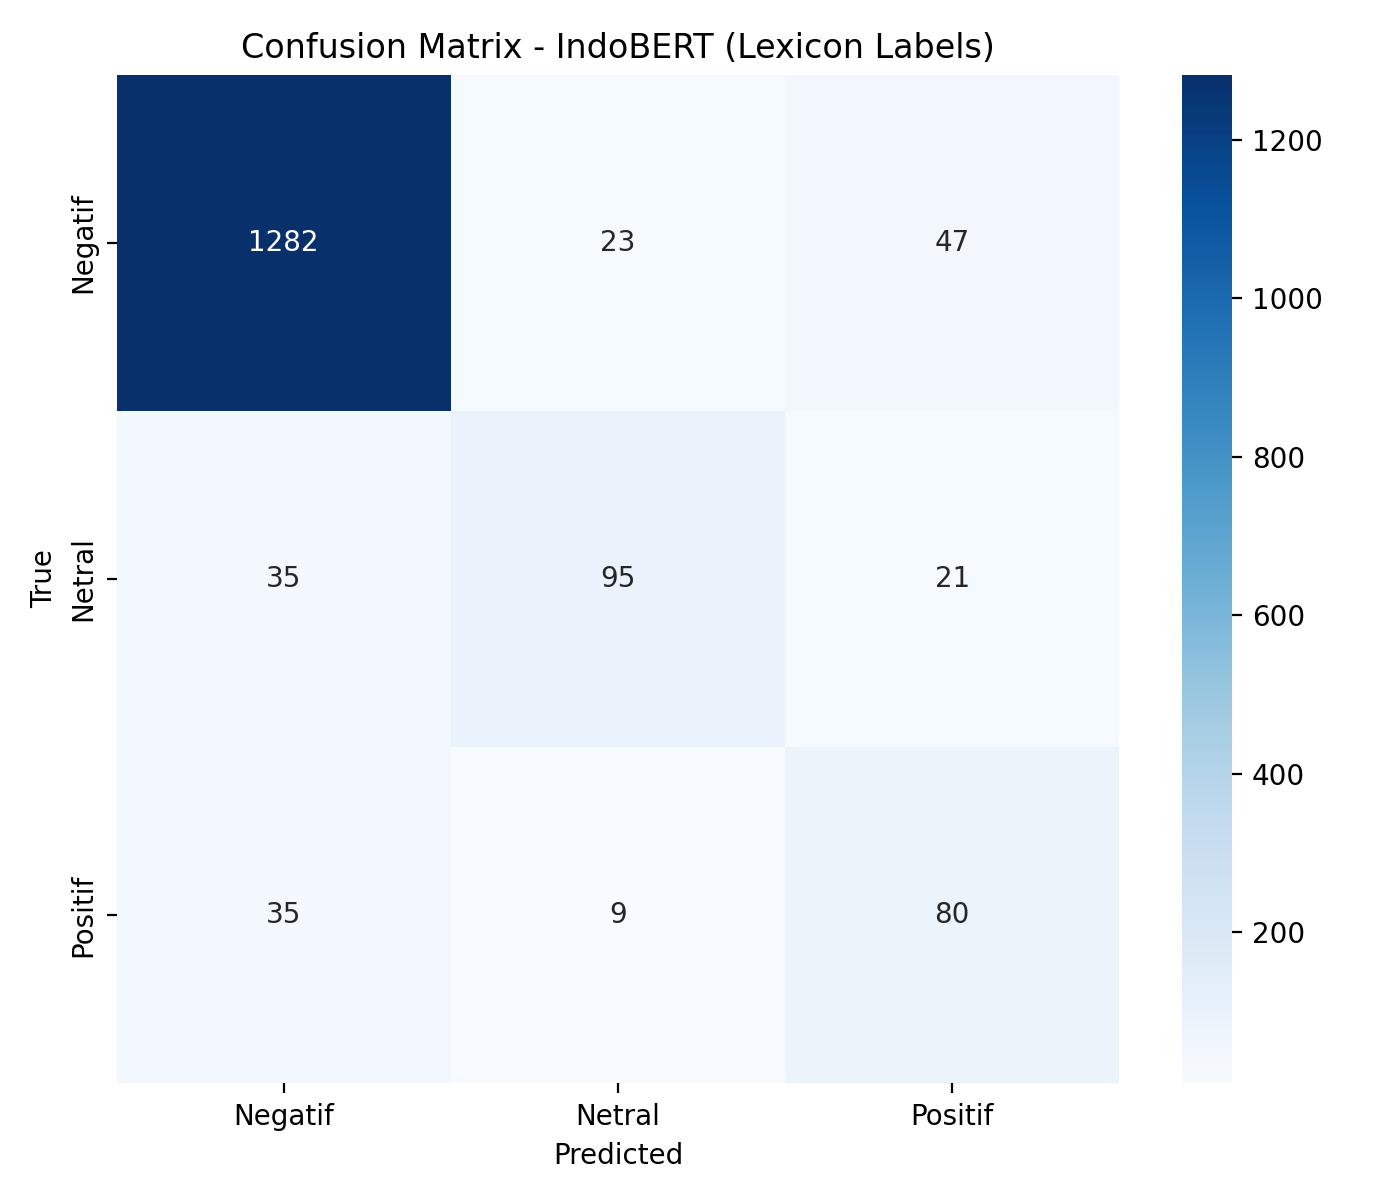

### CSV Preview: 05_youtube_predicted_by_lexicon_indobert.csv

- Rows: **10842**, Cols: **8**

,keyword,video_id,published_at,text,comment_id,text_cleaned,label_lex_indobert,score_lex_indobert
0,Board of Peace Indonesia,b1x3nSOumrc,2026-03-31 06:48:21+00:00,Aku setuju indonesia masuk BOP karena bennix (...,b1x3nSOumrc_2026-03-31T06:48:21Z_Aku setuju in...,aku setuju indonesia masuk board of peace kare...,negatif,0.998757
1,Board of Peace Indonesia,b1x3nSOumrc,2026-03-08 06:40:15+00:00,"Prabowo kena jebakan,blunder kan,hhhh,kasih pa...",b1x3nSOumrc_2026-03-08T06:40:15Z_Prabowo kena ...,prabowo kena jebakan blunder kan hhhh kasih pa...,negatif,0.992628
2,Board of Peace Indonesia,b1x3nSOumrc,2026-03-07 13:11:52+00:00,Solusi dua negara ? Sebuah kedunguan seorang k...,b1x3nSOumrc_2026-03-07T13:11:52Z_Solusi dua ne...,solusi dua negara sebuah kedunguan seorang kep...,negatif,0.997404
3,Board of Peace Indonesia,b1x3nSOumrc,2026-02-25 01:52:34+00:00,Indonesia blunder,b1x3nSOumrc_2026-02-25T01:52:34Z_Indonesia blu...,indonesia blunder,netral,0.997714
4,Board of Peace Indonesia,b1x3nSOumrc,2026-02-24 23:09:44+00:00,Yg lebih bikin bingung adalah presiden Wowo ik...,b1x3nSOumrc_2026-02-24T23:09:44Z_Yg lebih biki...,yang lebih bikin bingung adalah presiden wowo ...,negatif,0.997216


### Distribusi label: `label_lex_indobert`

label_lex_indobert
negatif    8943
netral      979
positif     920
Name: count, dtype: int64

### Gambar: lexicon_indobert_weekly_trend.png

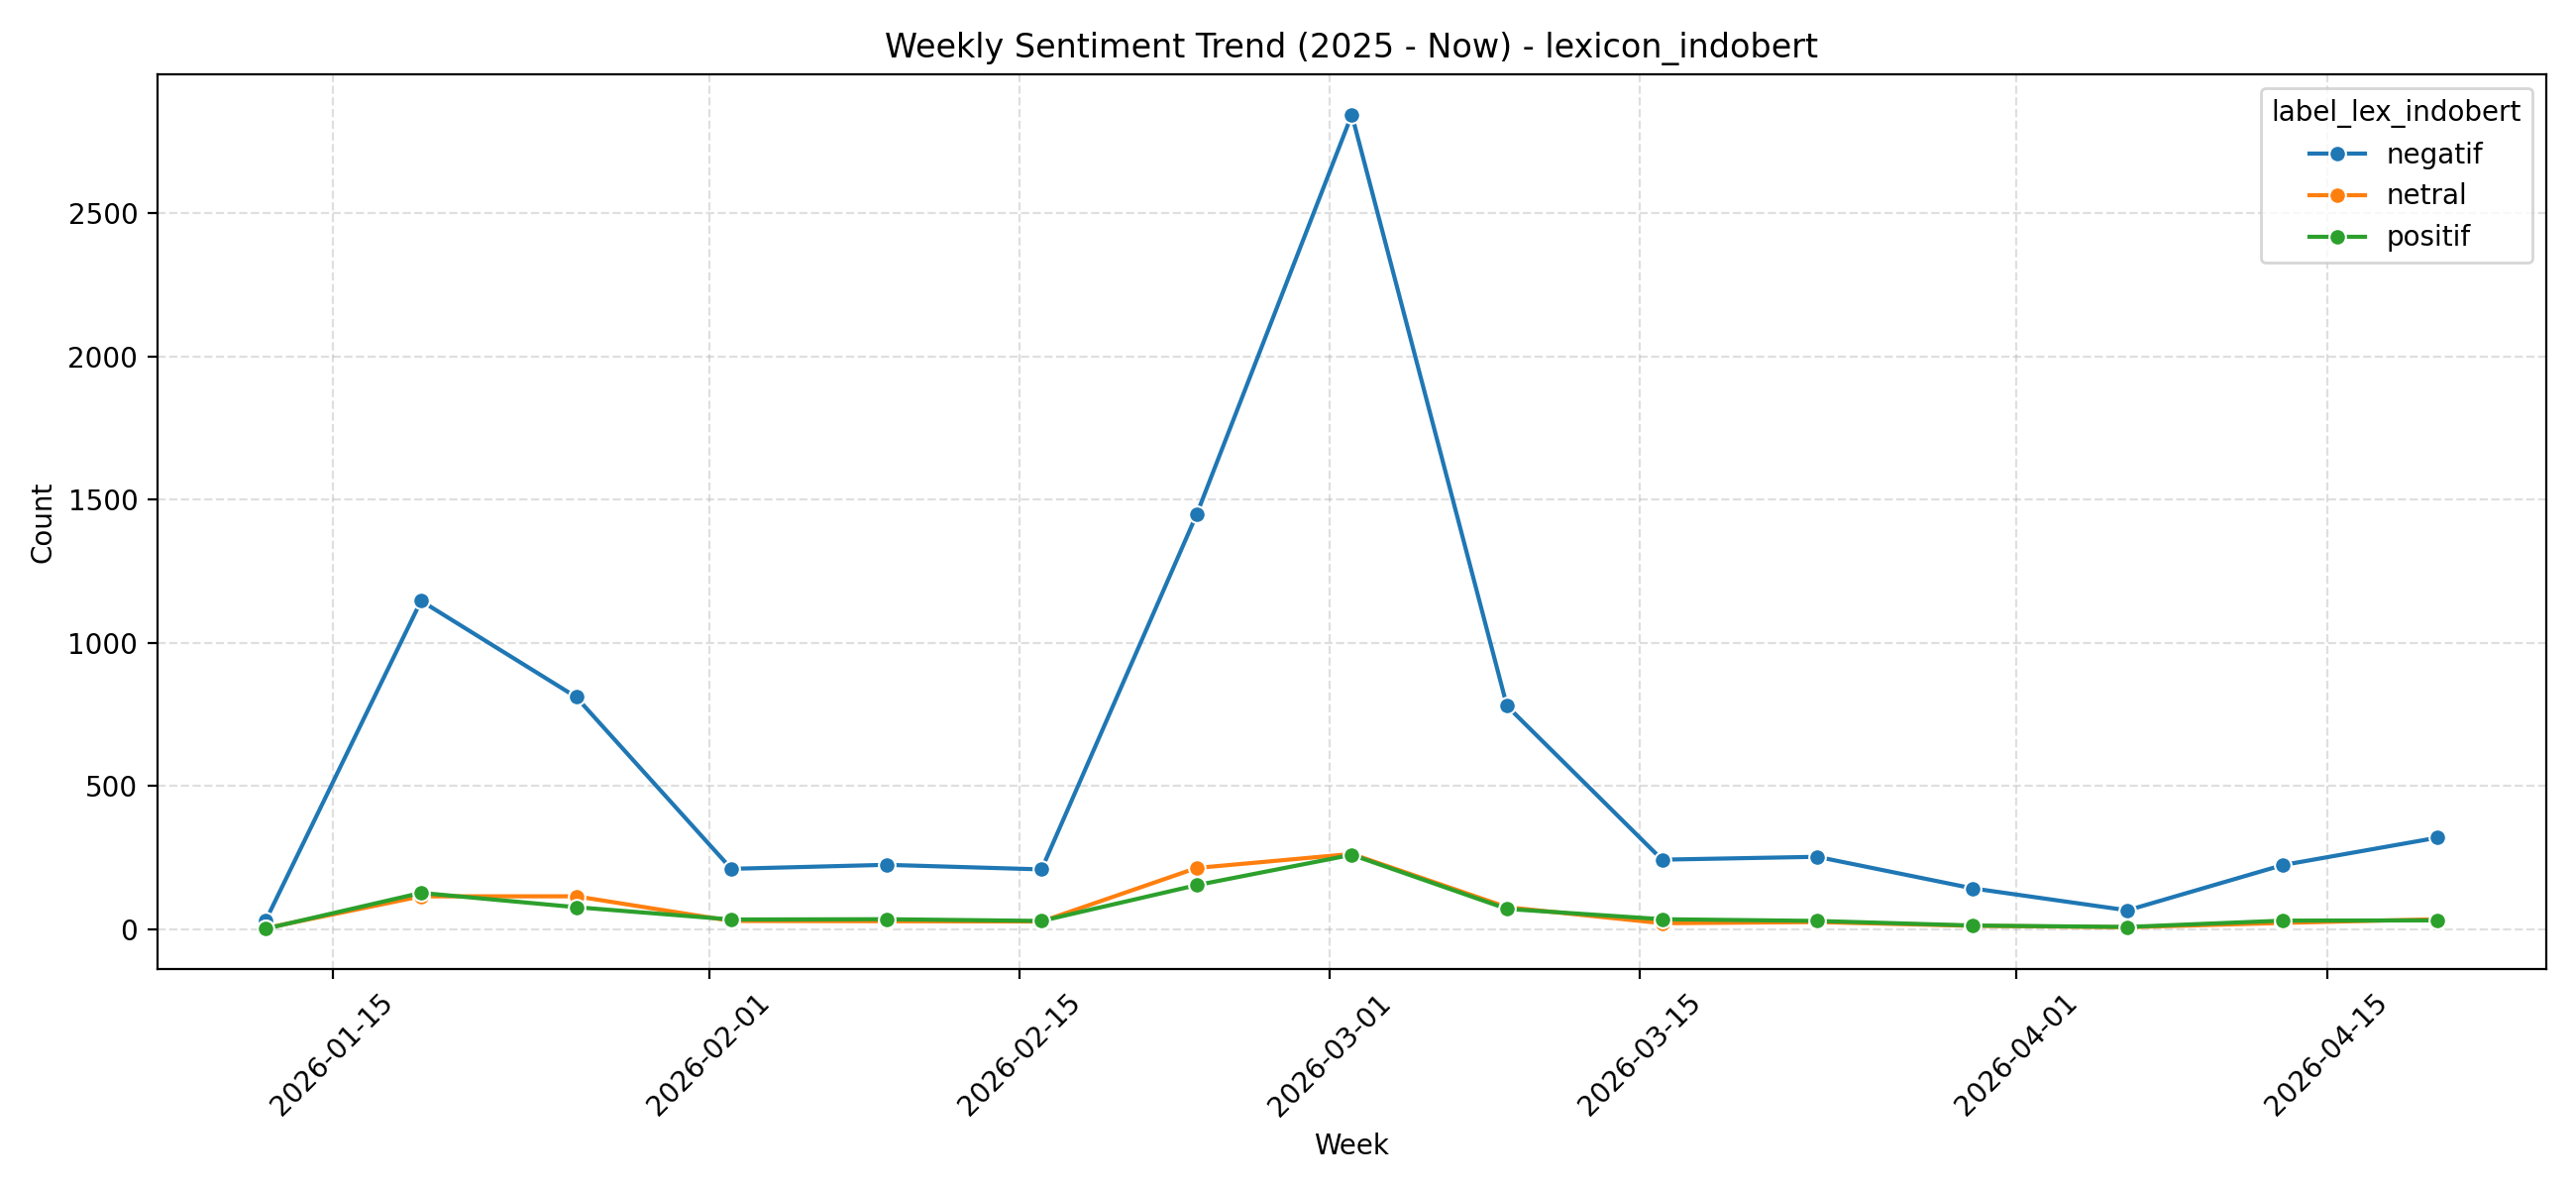

### Teks: lexicon_indobert_lda_topics.txt

== lexicon_indobert | negatif ==
Topic 1: iran, trump, as, perang, israel, dunia, amerika, antek, prabowo, takut
Topic 2: negara, of, bangsa, amerika, palestina, israel, dunia, prabowo, perdamaian, gaza
Topic 3: negara, rakyat, orang, mbg, sok, urus, omon, presiden, prabowo, wowo

== lexicon_indobert | netral ==
Topic 1: of, wowo, bangsa, pengamat, mbg, as, negara, perserikatan, perdamaian, wo
Topic 2: israel, iran, presiden, bowo, pemimpin, pahlawan, rakyat, orang, macan, bela
Topic 3: omon, trump, prabowo, amerika, konoha, blok, sok, si, urus, and

== lexicon_indobert | positif ==
Topic 1: bangsa, amerika, negara, trump, islam, harga, israel, iran, rakyat, palestina
Topic 2: the, presiden, of, and, as, to, in, iran, trump, is
Topic 3: ya, iran, prabowo, mantap, allah, percaya, mbg, presiden, dunia, israel




### Gambar: lexicon_indobert_wordcloud_negatif.png

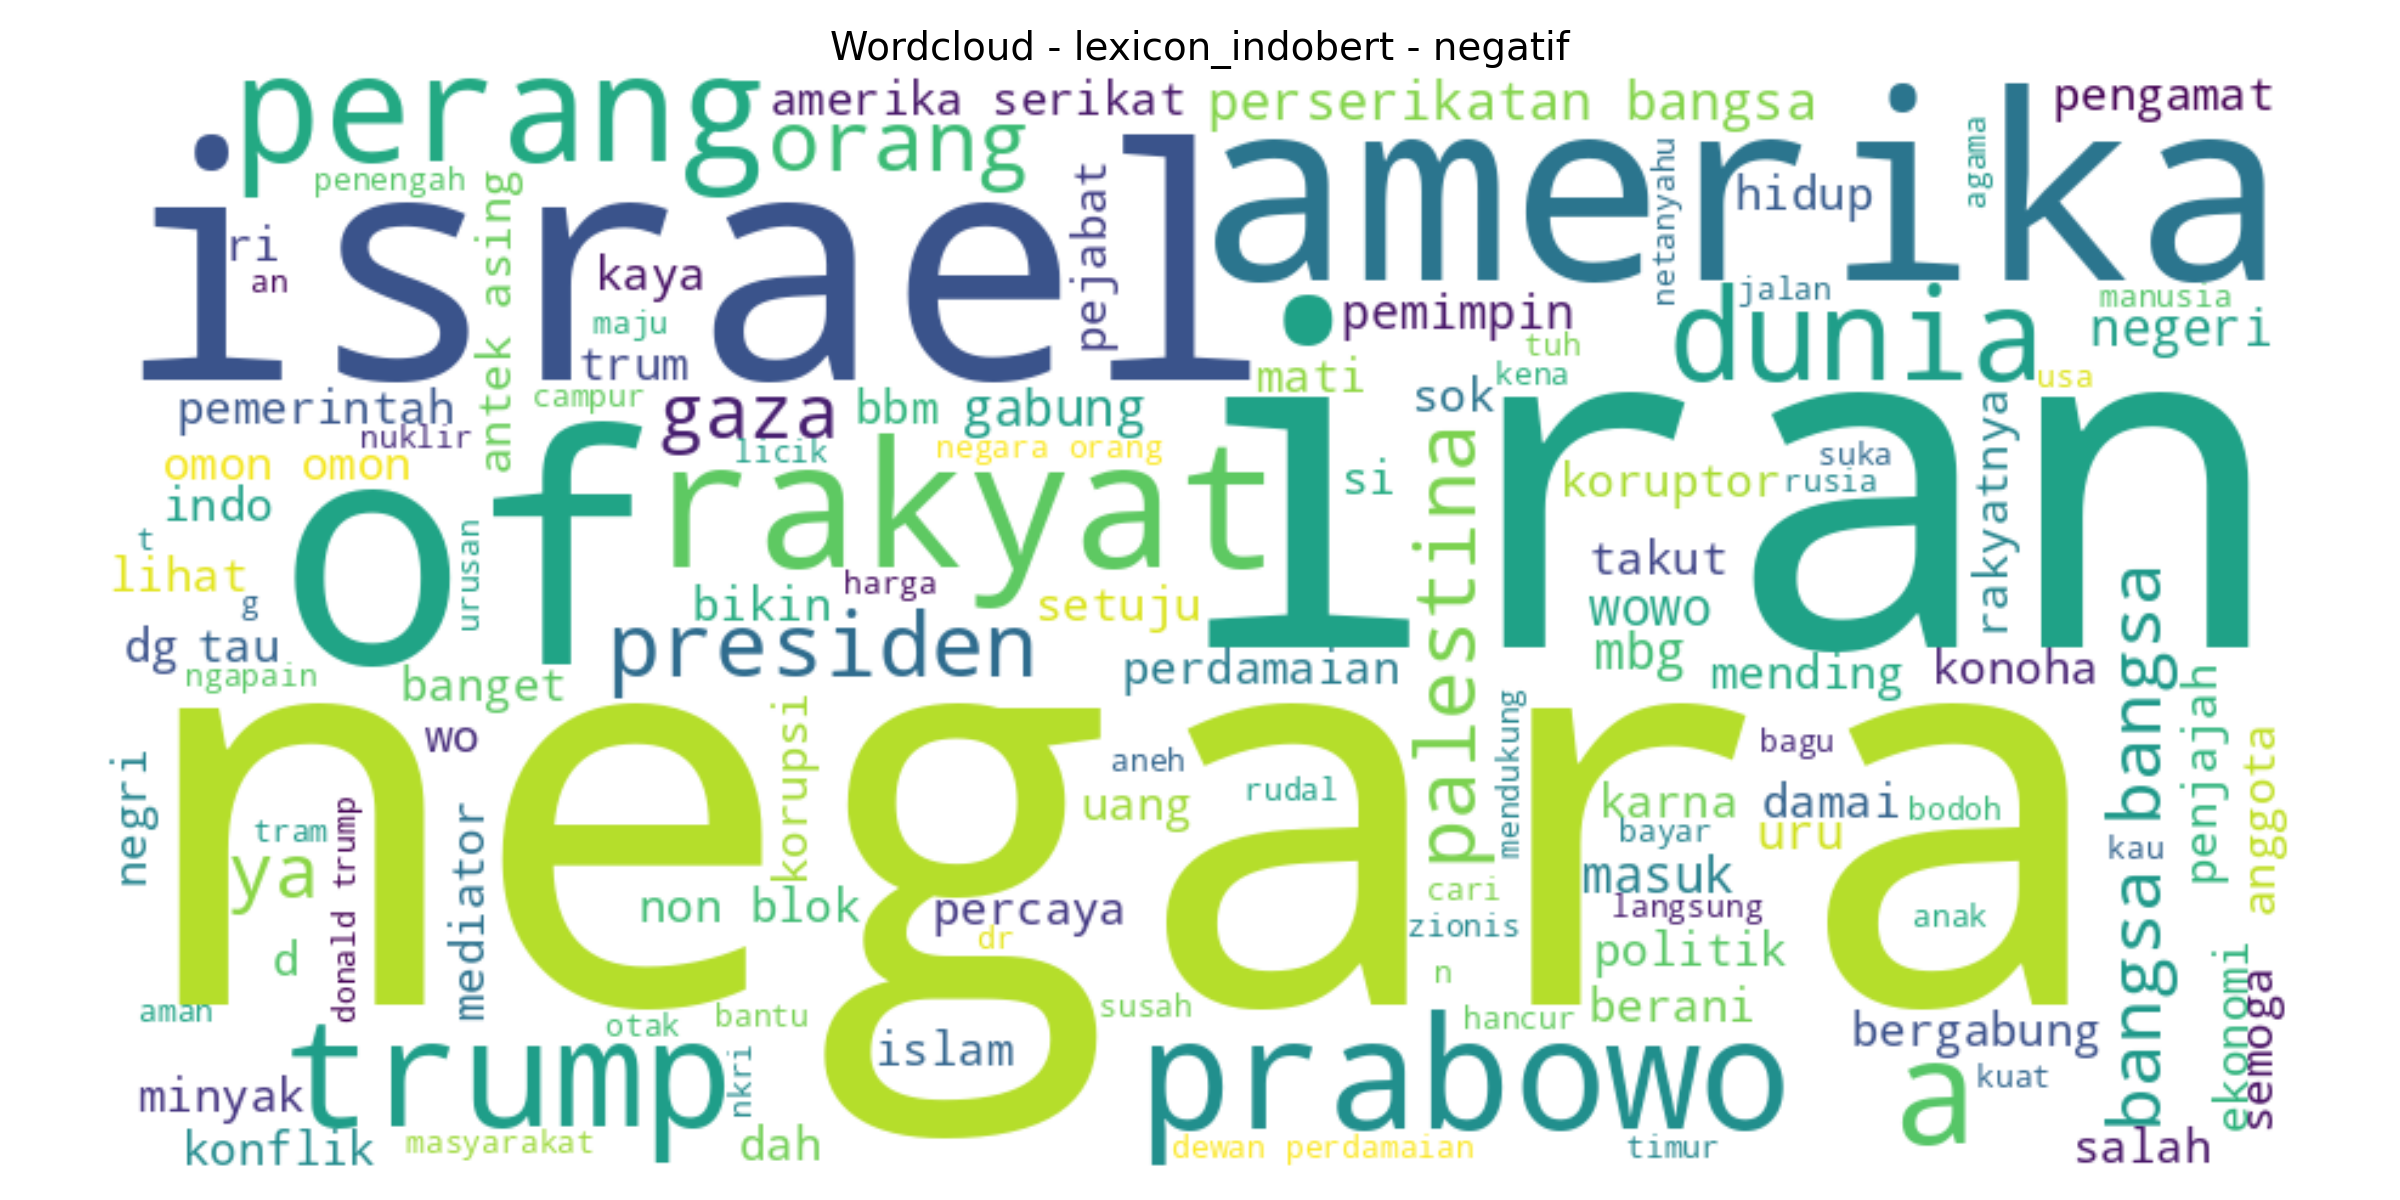

### Gambar: lexicon_indobert_wordcloud_netral.png

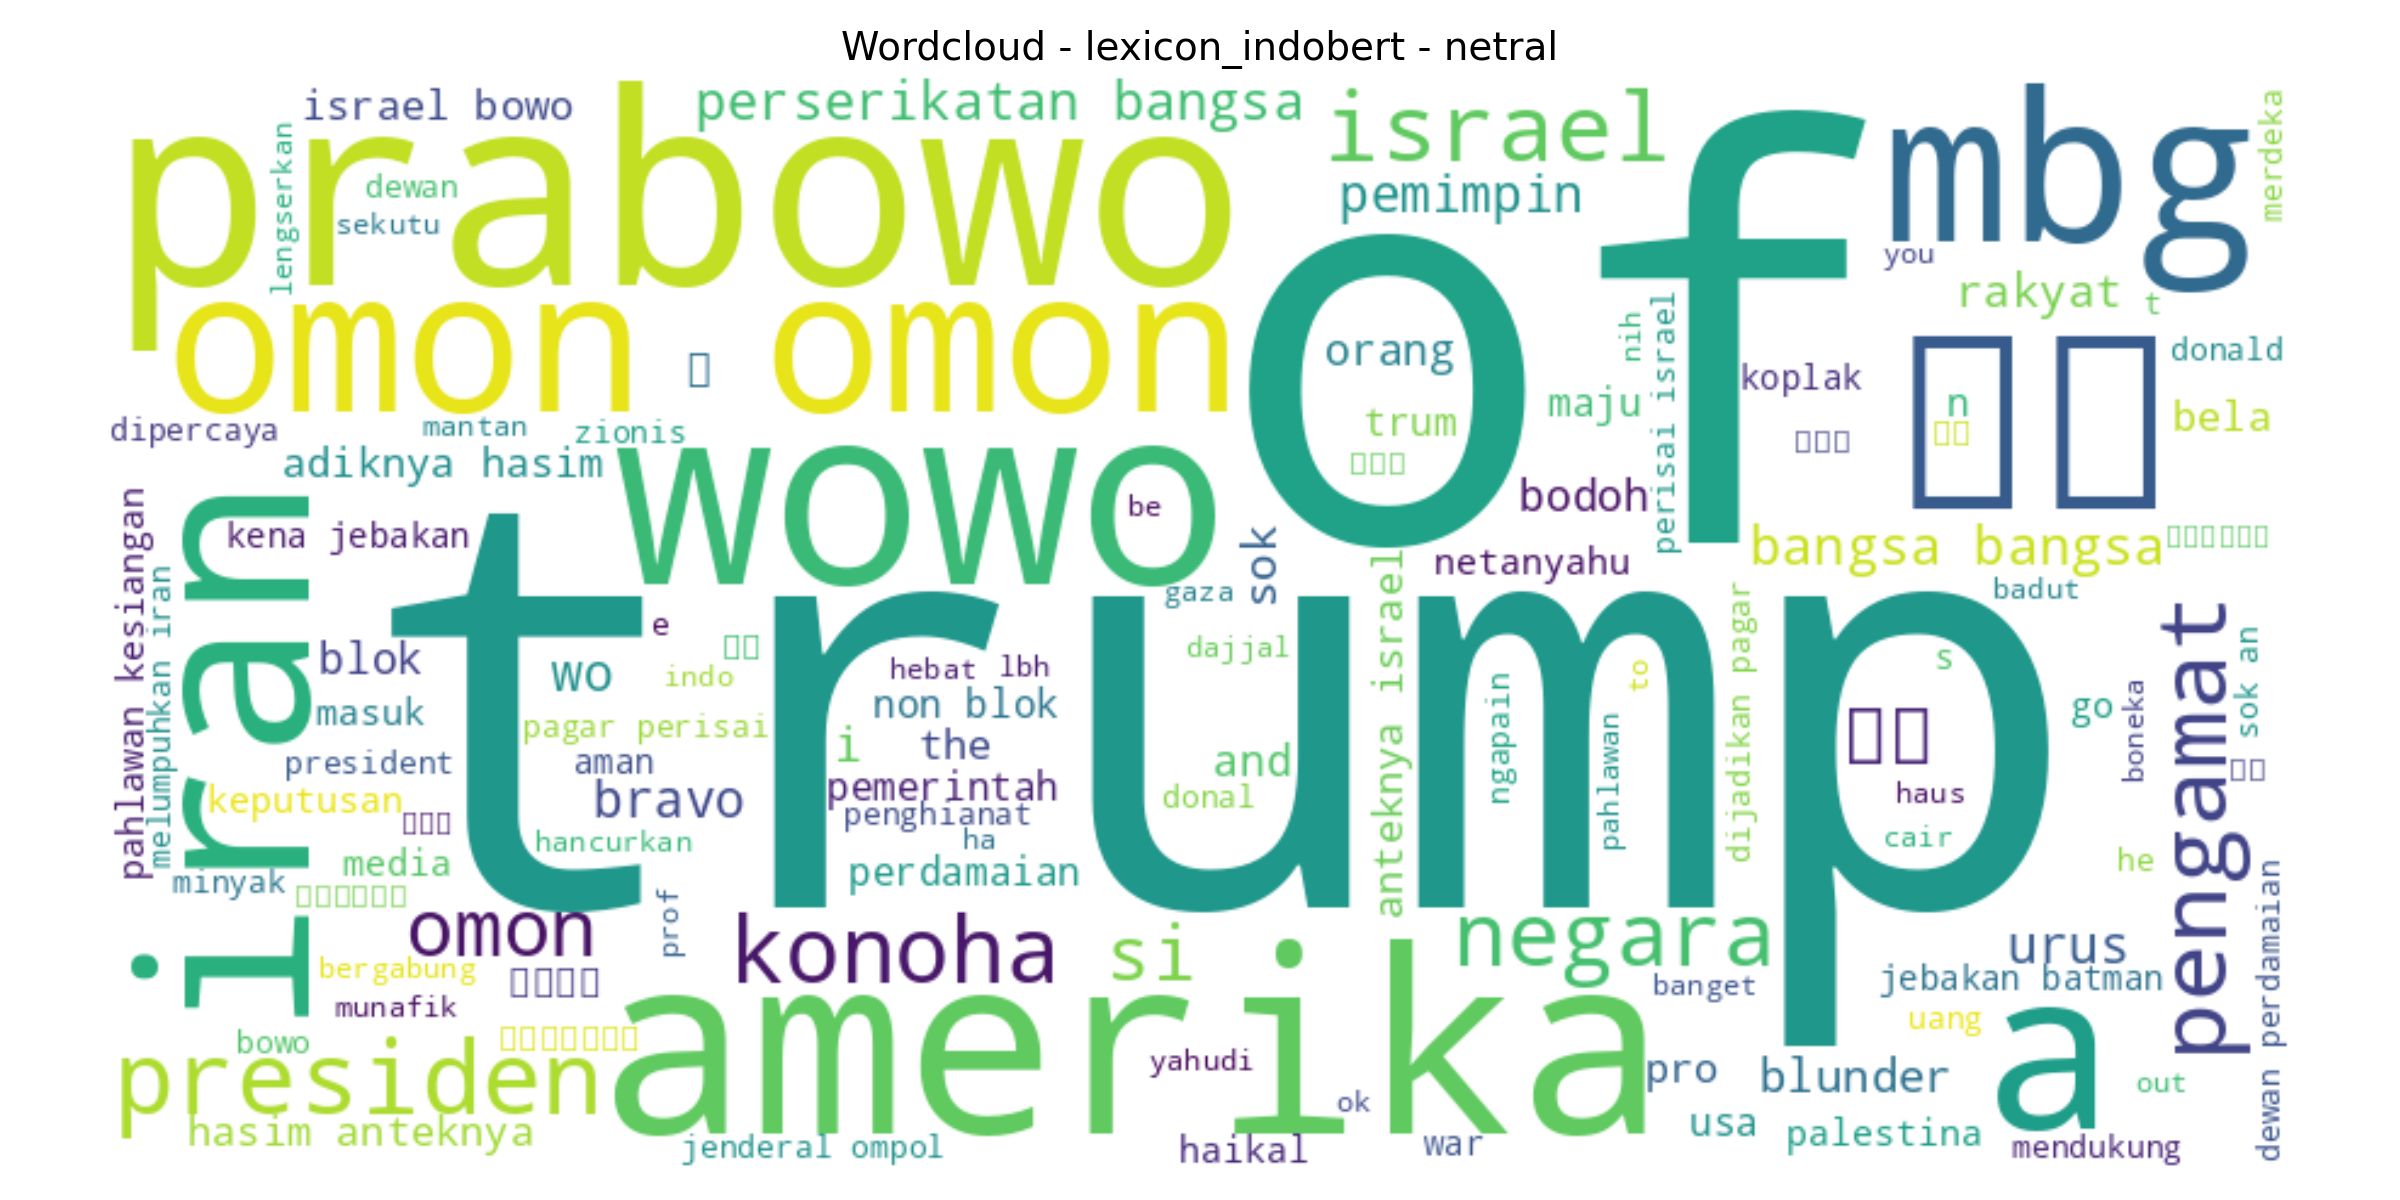

### Gambar: lexicon_indobert_wordcloud_positif.png

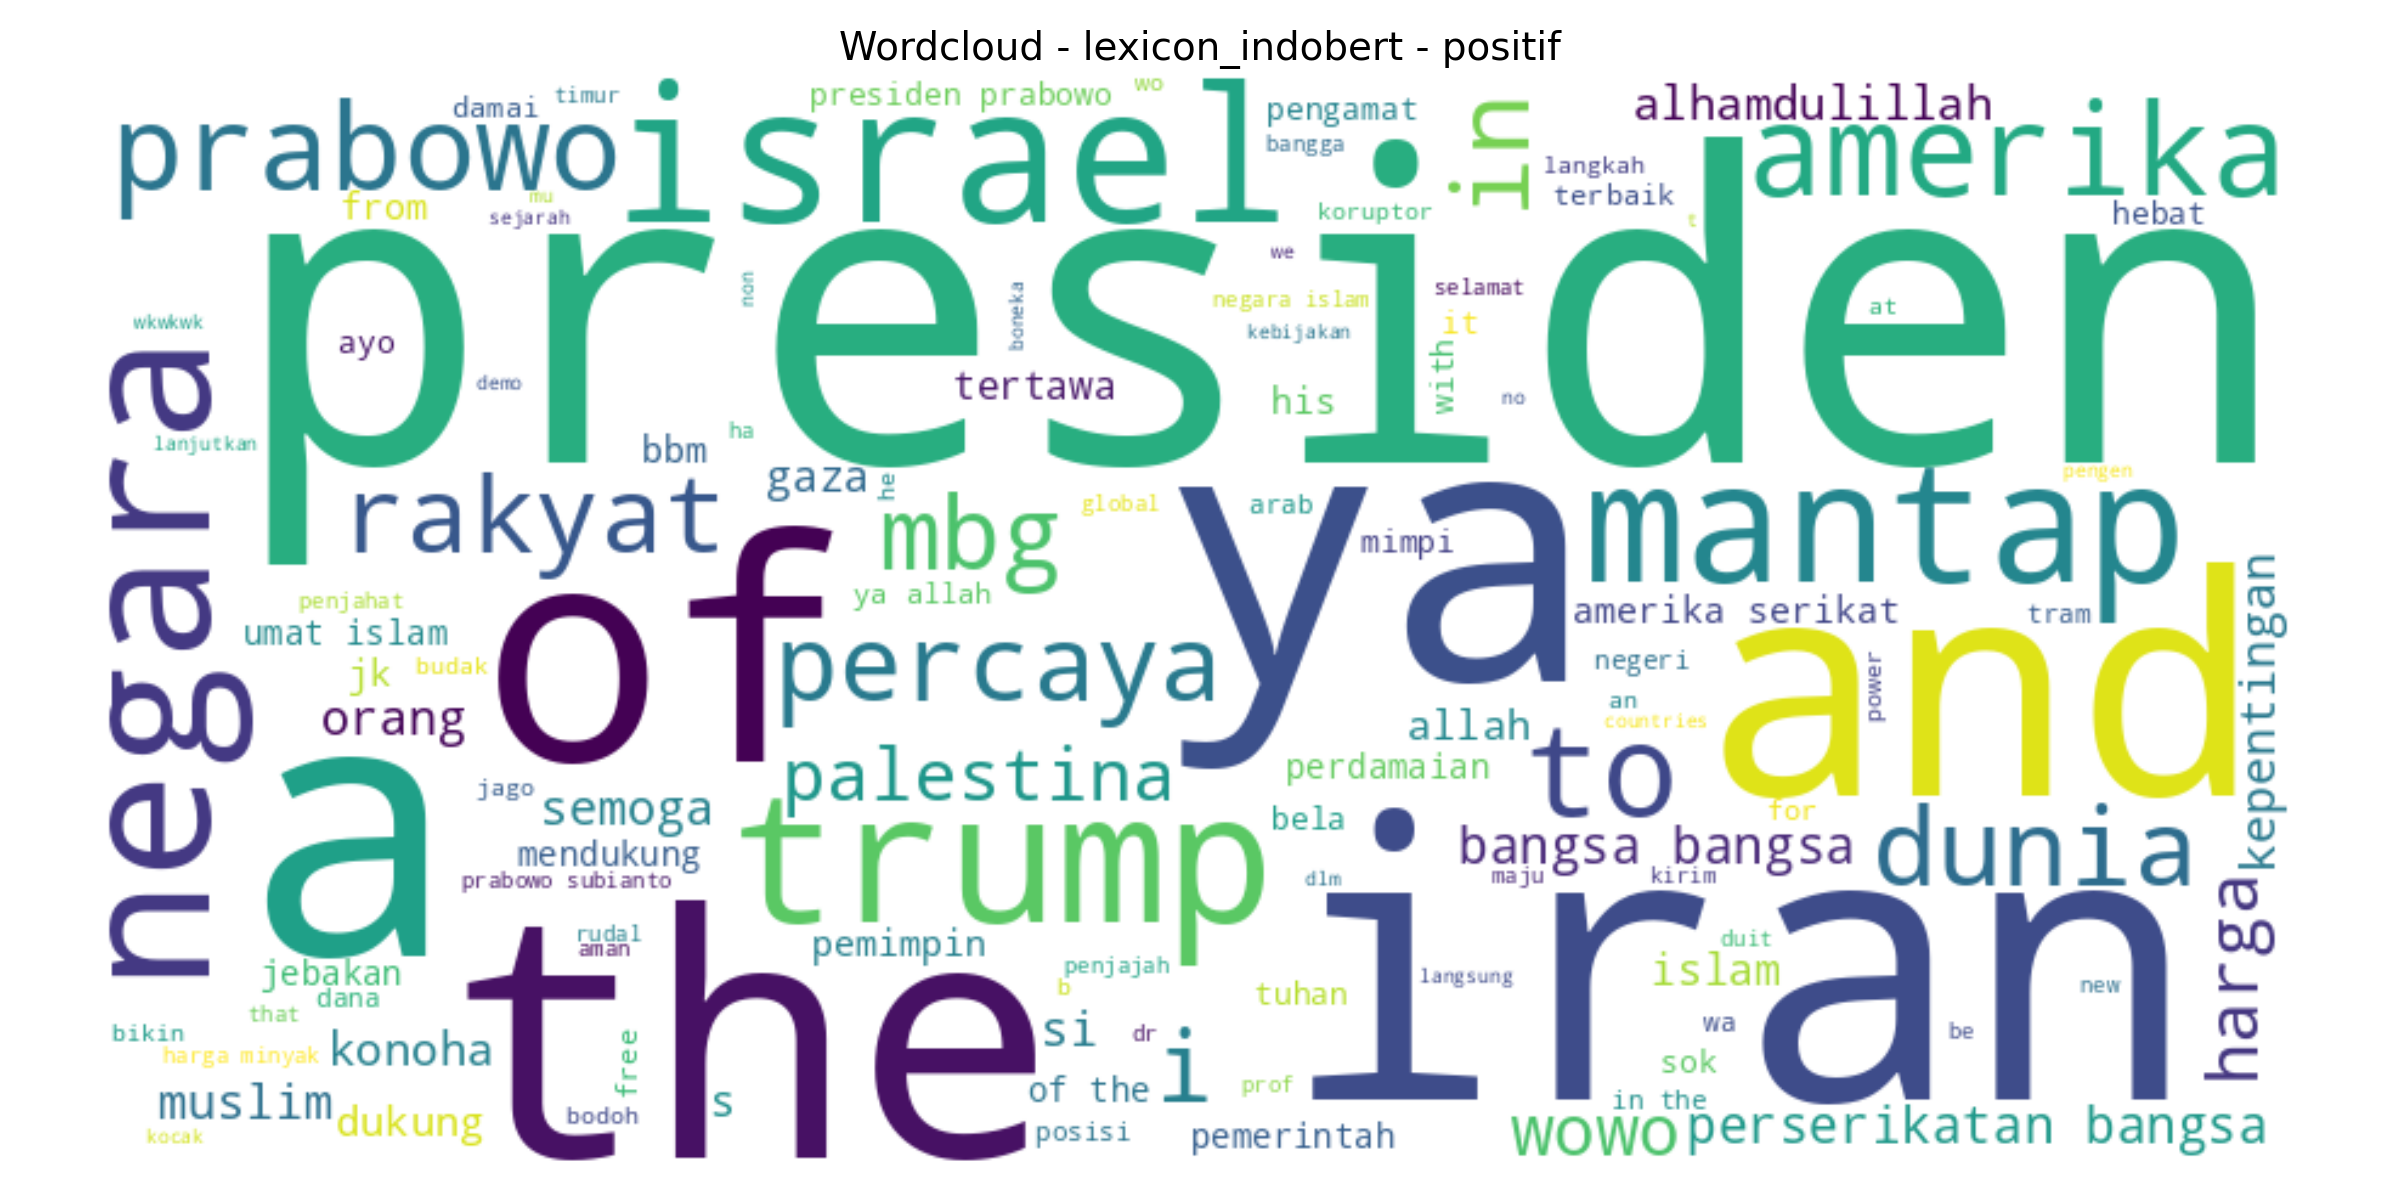

In [10]:
show_title("C. Metode 1 — IndoBERT dilatih dari Label Lexicon (InSet)")

# metrik test
show_json(files["lex_metrics"])
show_image(files["lex_cm"], width=750)

# hasil prediksi full youtube
df_lex_pred = show_csv_head(files["lex_pred"])
show_value_counts(df_lex_pred, "label_lex_indobert")

# trend + topics + wordcloud (kalau ada)
show_image(files["lex_trend"], width=1000)
show_text_file(files["lex_topics"], max_lines=120)

# wordcloud per label (loop)
lex_wc_dir = f"{REPORTS_DIR}/lexicon_indobert"
for lab in ["negatif", "netral", "positif"]:
    path = f"{lex_wc_dir}/lexicon_indobert_wordcloud_{lab}.png"
    show_image(path, width=900)

Metode 2 (SmSA → IndoBERT): metrik + confusion matrix + distribusi label + visual

## D. Metode 2 — IndoBERT Transfer Learning dari SmSA

### JSON: smsa_indobert_test_metrics.json

{'accuracy': 0.92,
 'precision': 0.9240555626230501,
 'recall': 0.92,
 'f1': 0.9168169941460227}

### Gambar: smsa_indobert_confusion_matrix.png

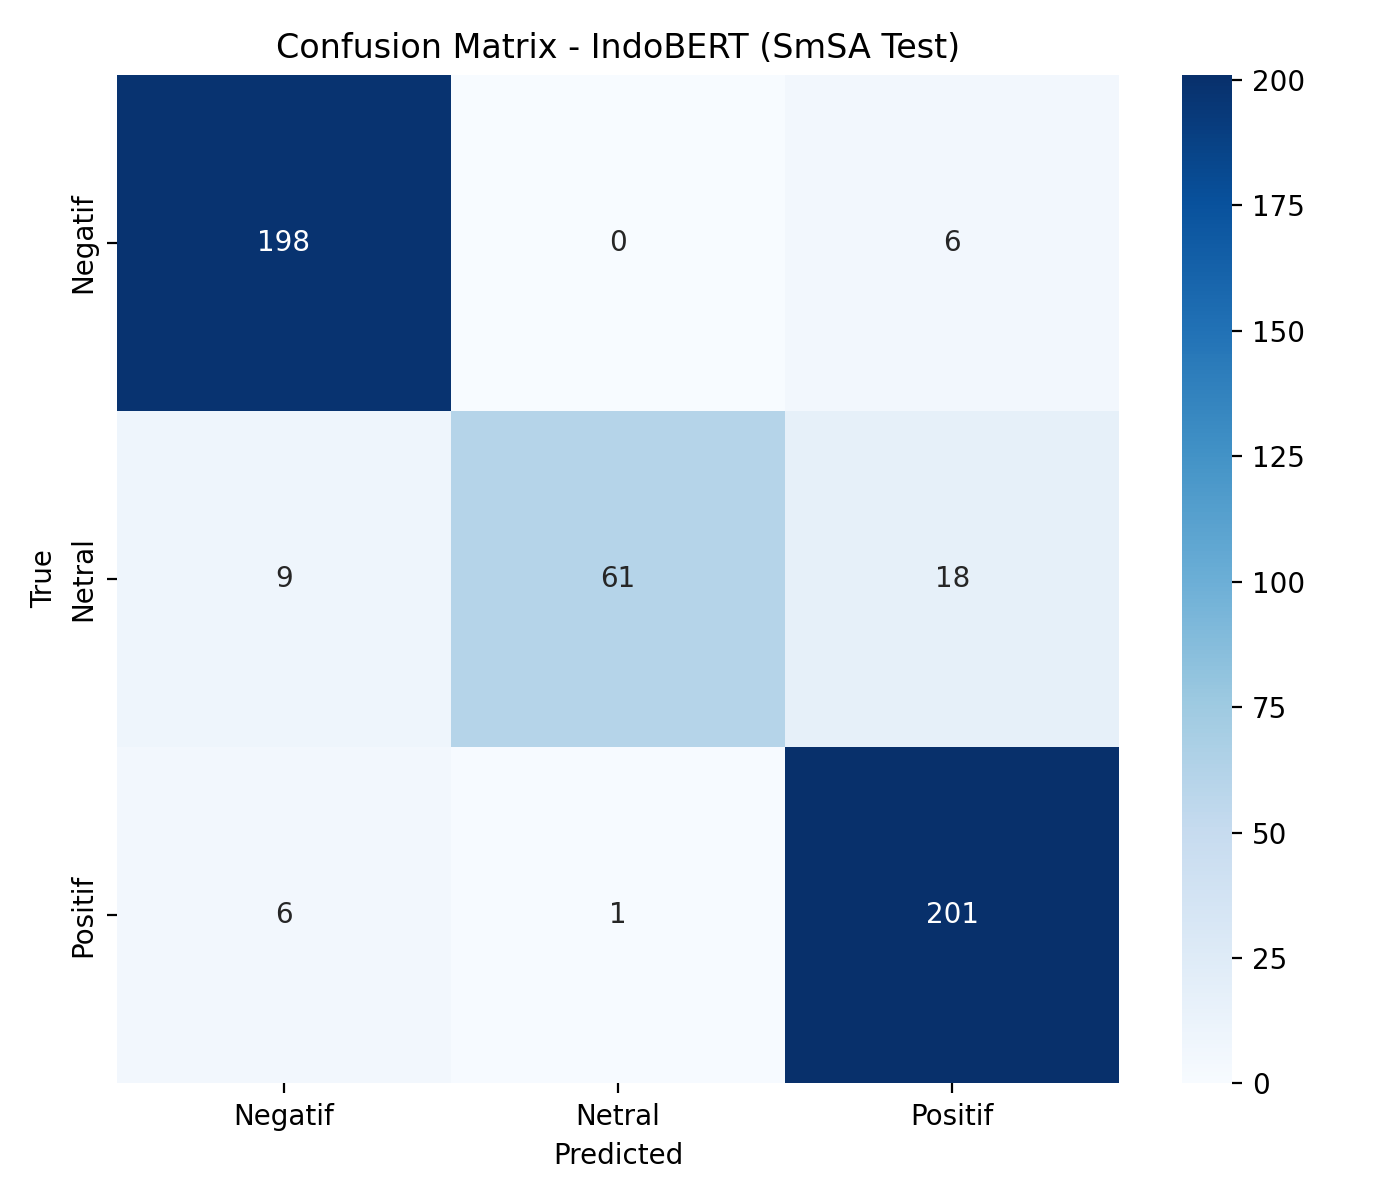

### CSV Preview: 06_youtube_predicted_by_smsa_indobert.csv

- Rows: **10842**, Cols: **8**

,keyword,video_id,published_at,text,comment_id,text_cleaned,label_smsa_indobert,score_smsa_indobert
0,Board of Peace Indonesia,b1x3nSOumrc,2026-03-31 06:48:21+00:00,Aku setuju indonesia masuk BOP karena bennix (...,b1x3nSOumrc_2026-03-31T06:48:21Z_Aku setuju in...,aku setuju indonesia masuk board of peace kare...,positif,0.792501
1,Board of Peace Indonesia,b1x3nSOumrc,2026-03-08 06:40:15+00:00,"Prabowo kena jebakan,blunder kan,hhhh,kasih pa...",b1x3nSOumrc_2026-03-08T06:40:15Z_Prabowo kena ...,prabowo kena jebakan blunder kan hhhh kasih pa...,negatif,0.995071
2,Board of Peace Indonesia,b1x3nSOumrc,2026-03-07 13:11:52+00:00,Solusi dua negara ? Sebuah kedunguan seorang k...,b1x3nSOumrc_2026-03-07T13:11:52Z_Solusi dua ne...,solusi dua negara sebuah kedunguan seorang kep...,negatif,0.987382
3,Board of Peace Indonesia,b1x3nSOumrc,2026-02-25 01:52:34+00:00,Indonesia blunder,b1x3nSOumrc_2026-02-25T01:52:34Z_Indonesia blu...,indonesia blunder,negatif,0.996174
4,Board of Peace Indonesia,b1x3nSOumrc,2026-02-24 23:09:44+00:00,Yg lebih bikin bingung adalah presiden Wowo ik...,b1x3nSOumrc_2026-02-24T23:09:44Z_Yg lebih biki...,yang lebih bikin bingung adalah presiden wowo ...,negatif,0.750986


### Distribusi label: `label_smsa_indobert`

label_smsa_indobert
negatif    7700
positif    1784
netral     1358
Name: count, dtype: int64

### Gambar: smsa_indobert_weekly_trend.png

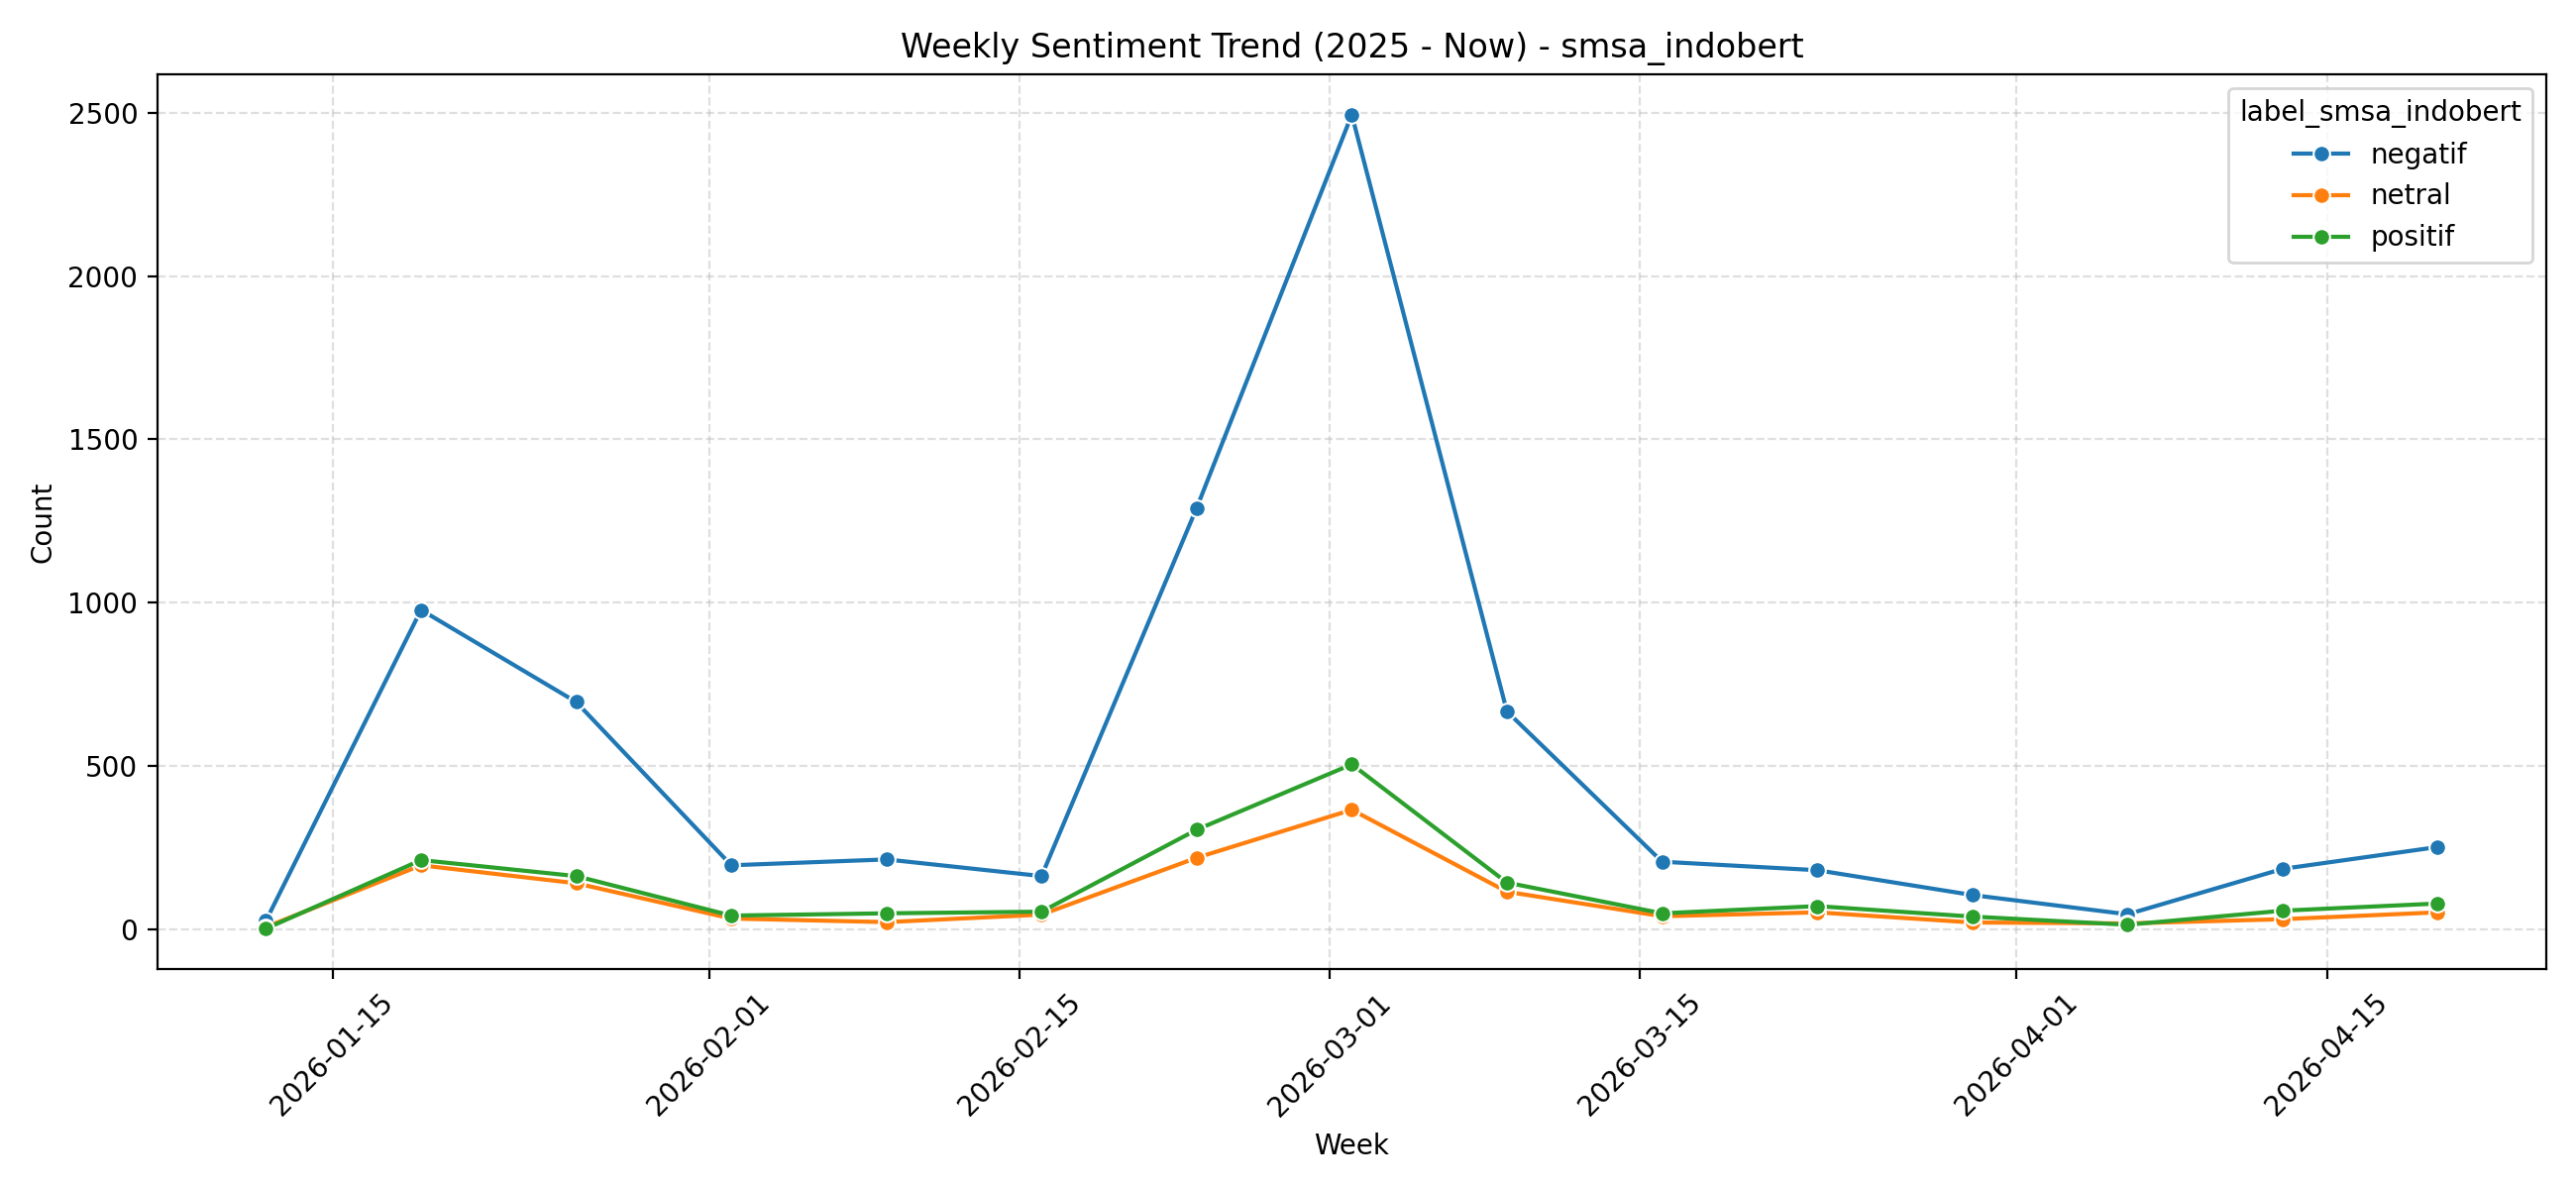

### Teks: smsa_indobert_lda_topics.txt

== smsa_indobert | negatif ==
Topic 1: iran, amerika, israel, as, palestina, of, perang, omon, gaza, rakyat
Topic 2: negara, trump, bangsa, orang, urus, mbg, rakyat, sok, wowo, dunia
Topic 3: prabowo, presiden, rakyat, ya, pengamat, orang, dunia, perang, sok, tau

== smsa_indobert | netral ==
Topic 1: bangsa, prabowo, perang, perserikatan, dunia, bbm, minyak, presiden, wowo, of
Topic 2: of, the, as, iran, israel, and, to, trump, rudal, in
Topic 3: negara, trump, perdamaian, iran, amerika, palestina, mbg, omon, blok, negeri

== smsa_indobert | positif ==
Topic 1: iran, prabowo, as, wowo, mantap, israel, trump, negara, presiden, setuju
Topic 2: negara, amerika, bangsa, dunia, perang, orang, prabowo, bbm, trump, percaya
Topic 3: palestina, of, gaza, semoga, perdamaian, negara, dunia, presiden, mbg, bagus




### Gambar: smsa_indobert_wordcloud_negatif.png

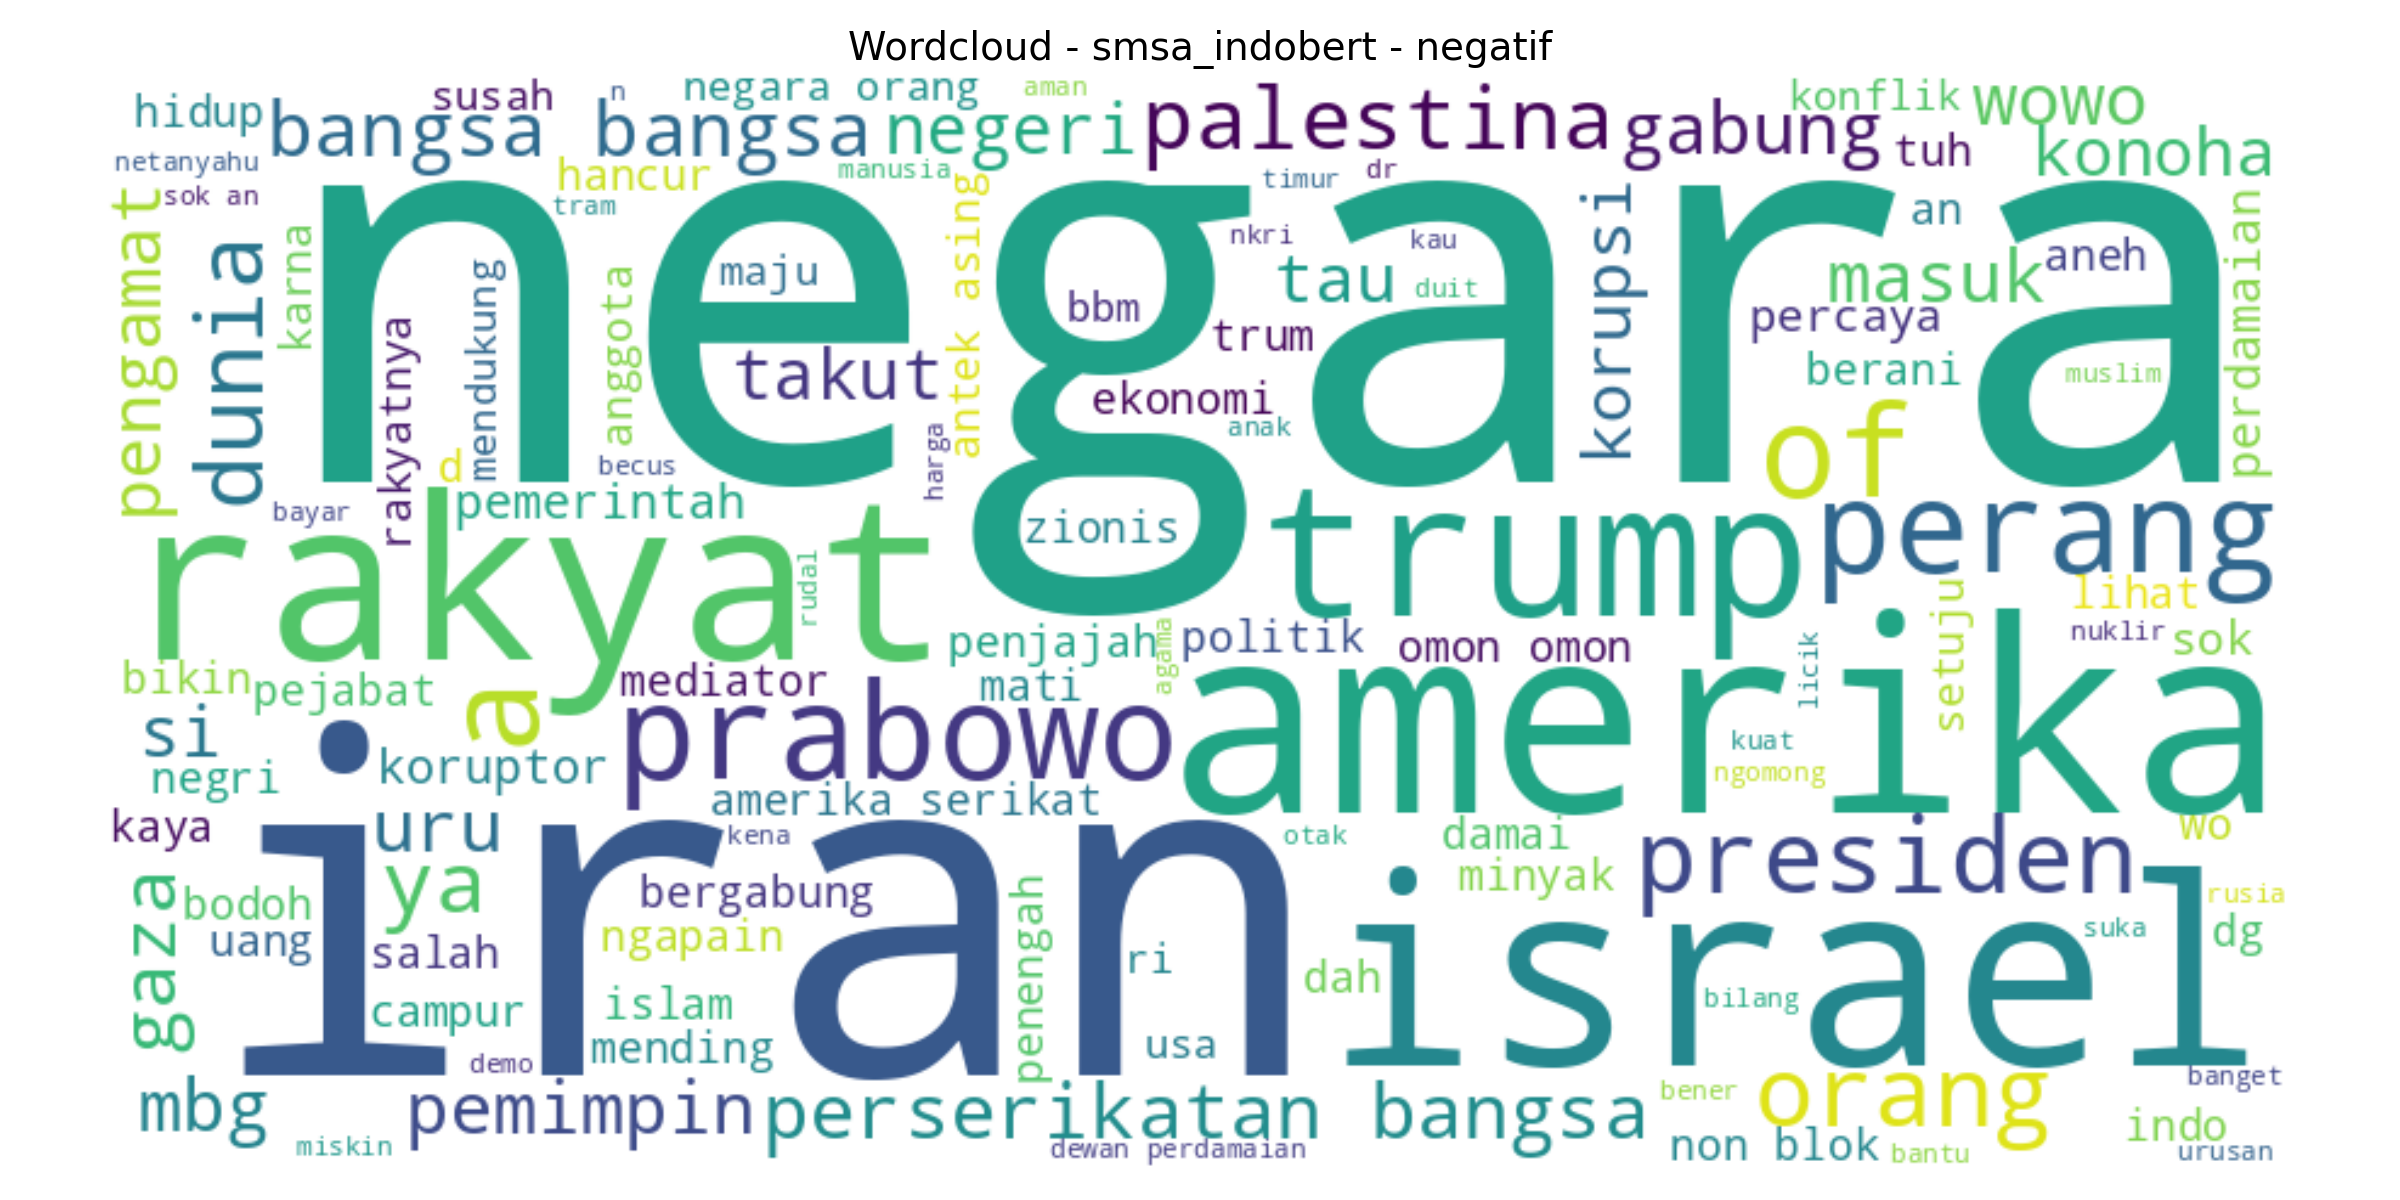

### Gambar: smsa_indobert_wordcloud_netral.png

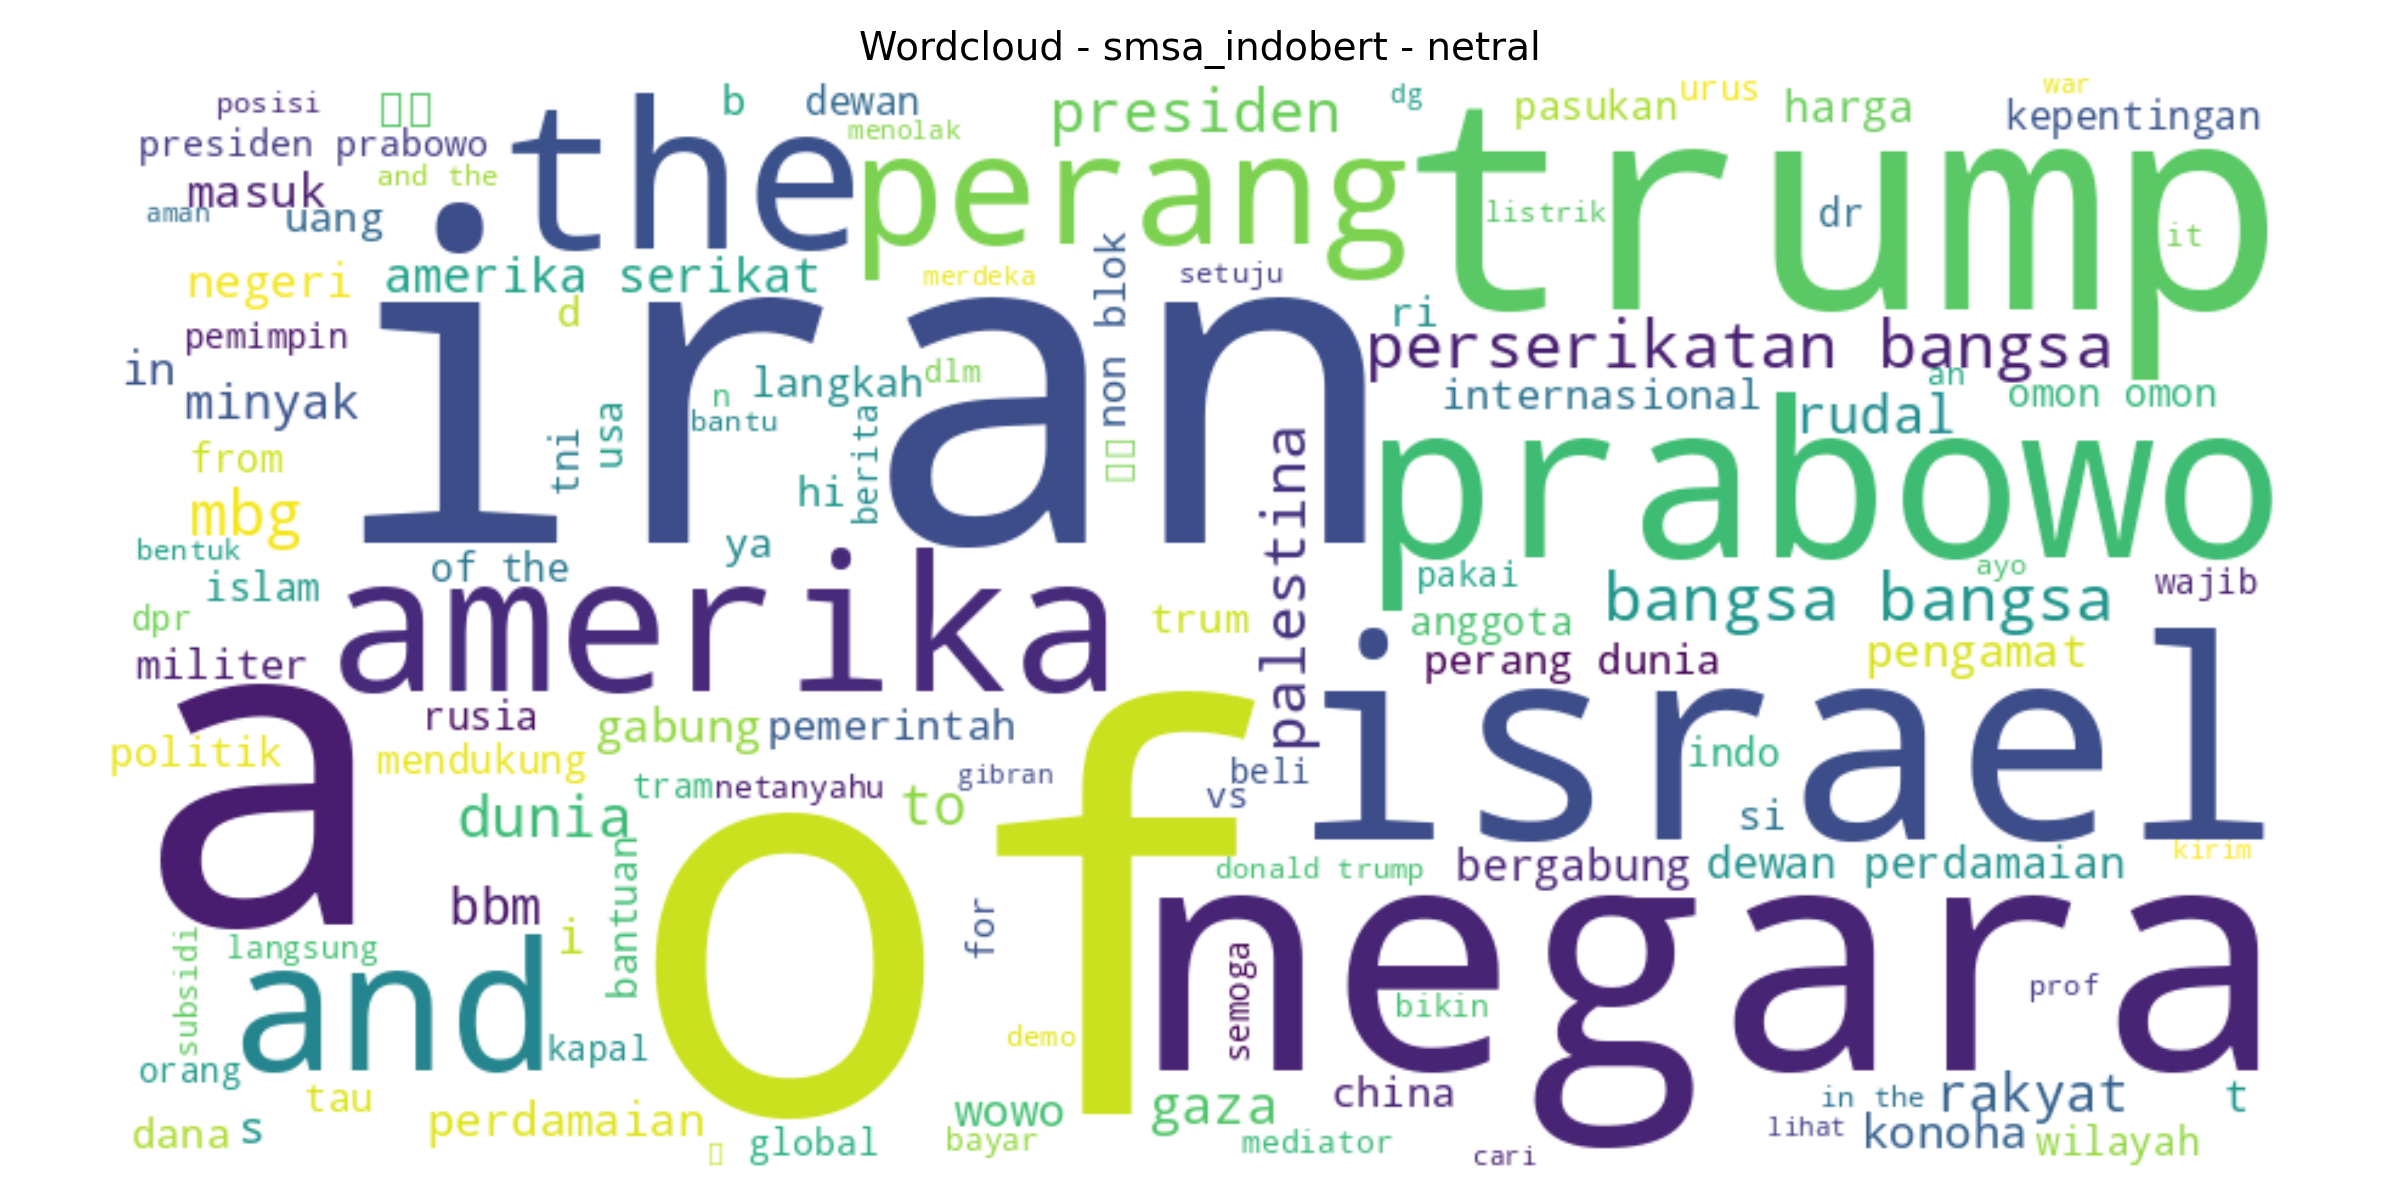

### Gambar: smsa_indobert_wordcloud_positif.png

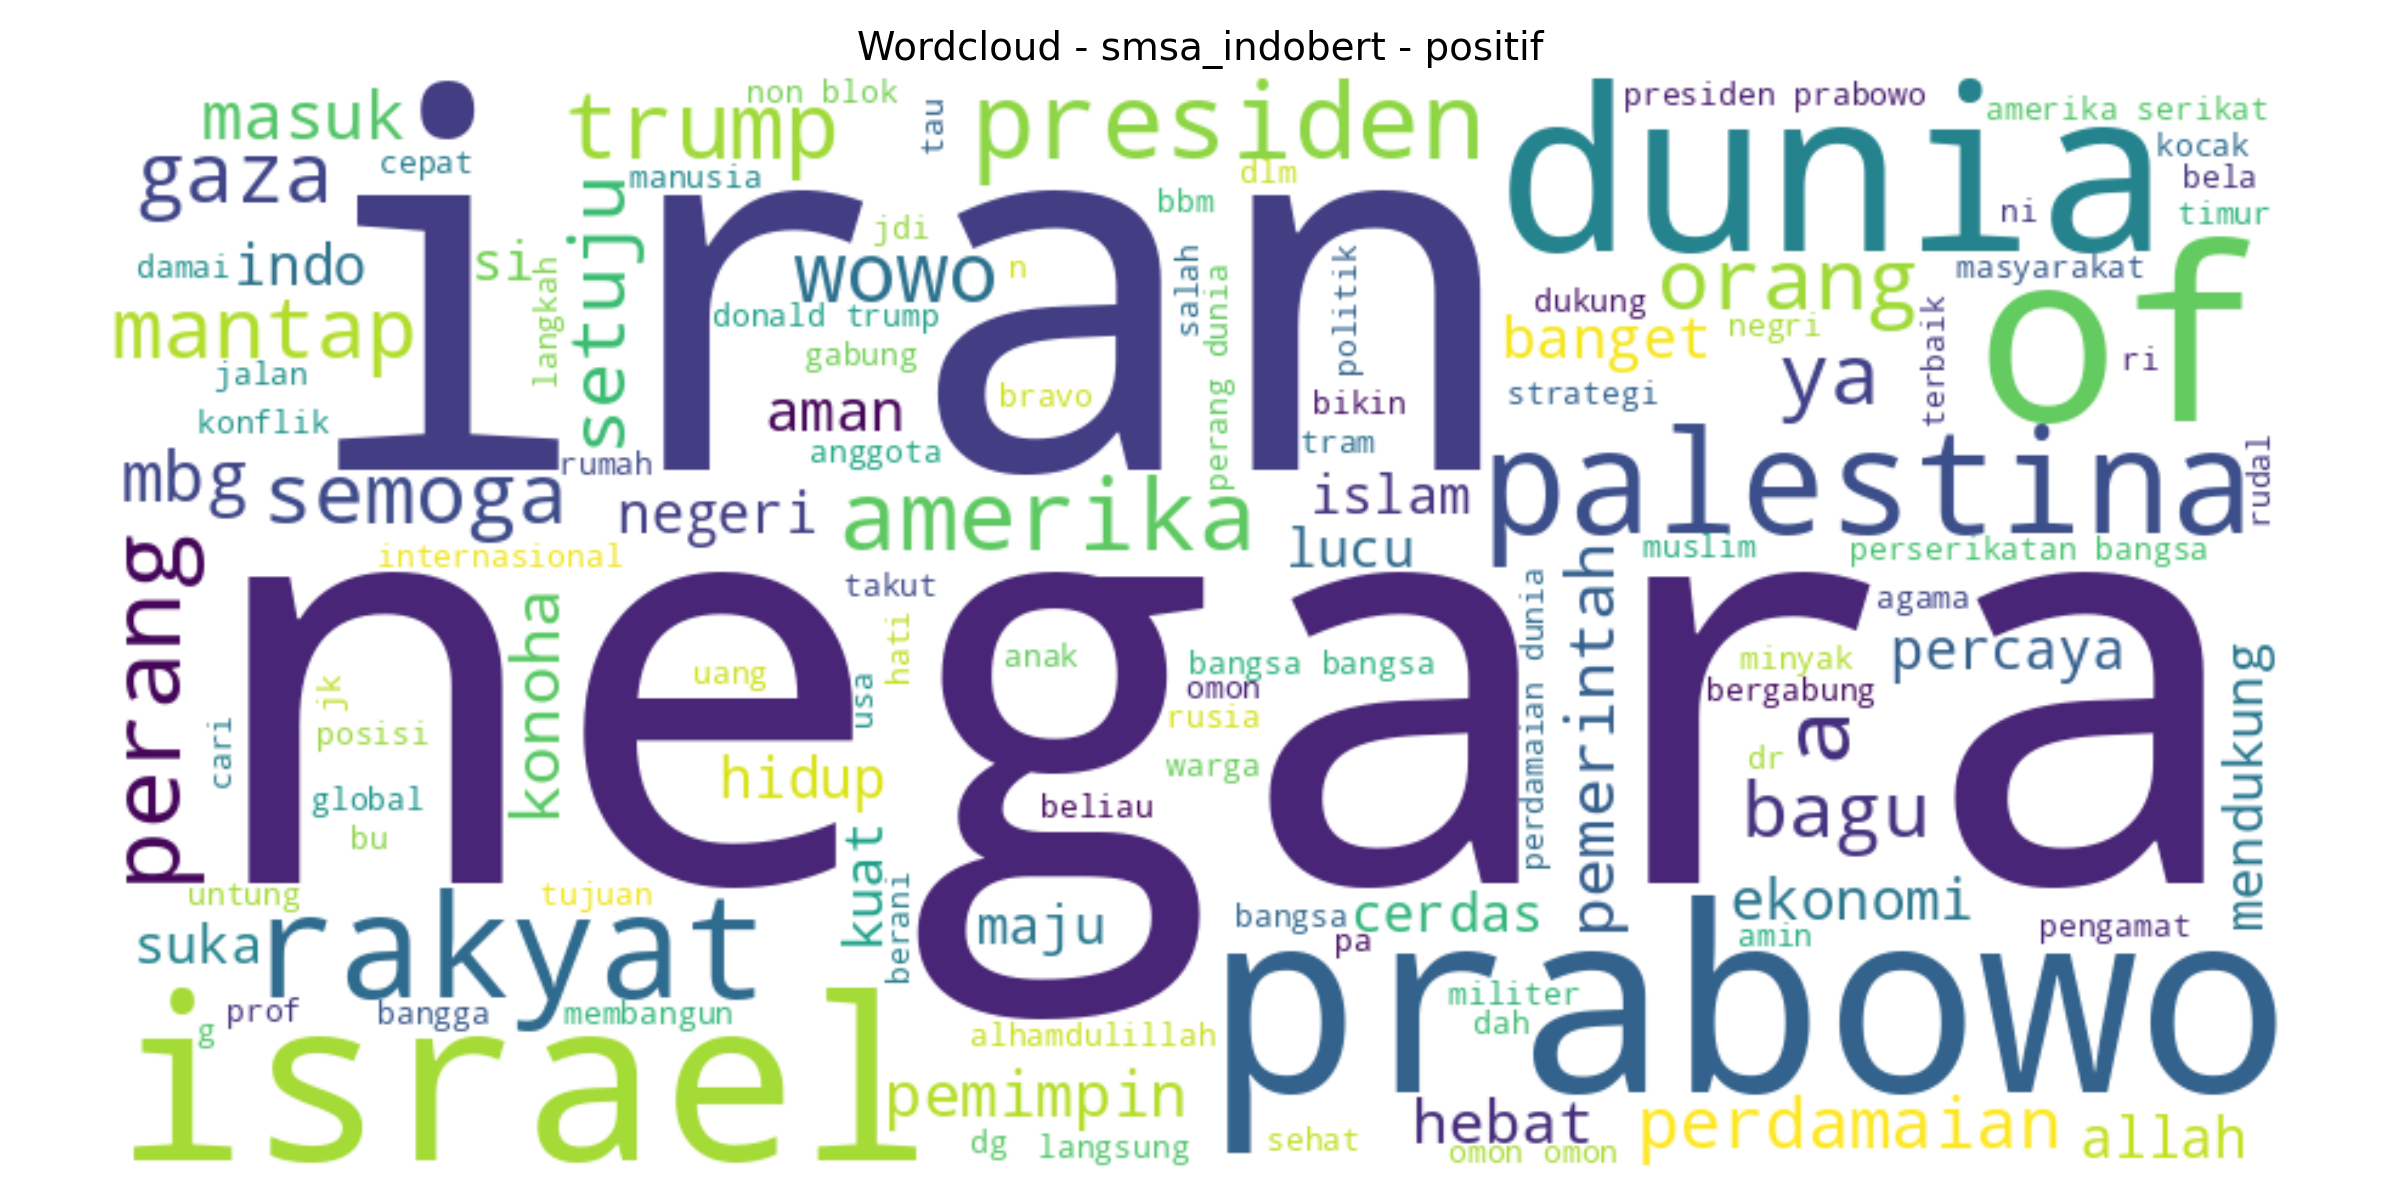

In [11]:
show_title("D. Metode 2 — IndoBERT Transfer Learning dari SmSA")

# metrik test SmSA
show_json(files["smsa_metrics"])
show_image(files["smsa_cm"], width=750)

# hasil prediksi full youtube
df_smsa_pred = show_csv_head(files["smsa_pred"])
show_value_counts(df_smsa_pred, "label_smsa_indobert")

# trend + topics + wordcloud
show_image(files["smsa_trend"], width=1000)
show_text_file(files["smsa_topics"], max_lines=120)

smsa_wc_dir = f"{REPORTS_DIR}/smsa_indobert"
for lab in ["negatif", "netral", "positif"]:
    path = f"{smsa_wc_dir}/smsa_indobert_wordcloud_{lab}.png"
    show_image(path, width=900)

Tabel komparasi ringkas

In [12]:
show_title("E. Komparasi Singkat (Ringkasan)")

# ambil metrik json kalau ada
lex_metrics = None
smsa_metrics = None
if os.path.exists(files["lex_metrics"]):
    with open(files["lex_metrics"], "r", encoding="utf-8") as f:
        lex_metrics = json.load(f)
if os.path.exists(files["smsa_metrics"]):
    with open(files["smsa_metrics"], "r", encoding="utf-8") as f:
        smsa_metrics = json.load(f)

rows = []
if lex_metrics:
    rows.append({"Metode": "Lexicon -> IndoBERT (test split label lexicon)", **lex_metrics})
if smsa_metrics:
    rows.append({"Metode": "SmSA -> IndoBERT (test SmSA)", **smsa_metrics})

if rows:
    df_cmp = pd.DataFrame(rows)
    display(df_cmp)
else:
    print("Tidak ada file metrics JSON yang ditemukan.")

## E. Komparasi Singkat (Ringkasan)

,Metode,accuracy,precision,recall,f1
0,Lexicon -> IndoBERT (test split label lexicon),0.895513,0.898574,0.895513,0.896215
1,SmSA -> IndoBERT (test SmSA),0.920000,0.924056,0.920000,0.916817


Testing Model Manual

In [13]:
# === Manual quick test (1-cell) for BOTH models ===
import os, torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/Board of Peace/"
MODEL_LEX_DIR  = os.path.join(BASE_DIR, "models/lexicon_indobert_model")
MODEL_SMSA_DIR = os.path.join(BASE_DIR, "models/smsa_indobert_model")

device = 0 if torch.cuda.is_available() else -1
FALLBACK = {"LABEL_0": "negatif", "LABEL_1": "netral", "LABEL_2": "positif"}

def load_pipe(model_dir):
    tok = AutoTokenizer.from_pretrained(model_dir)
    mdl = AutoModelForSequenceClassification.from_pretrained(model_dir)
    return pipeline("text-classification", model=mdl, tokenizer=tok, device=device)

pipe_lex  = load_pipe(MODEL_LEX_DIR)
pipe_smsa = load_pipe(MODEL_SMSA_DIR)

def predict(text: str):
    text = (text or "").strip()
    if not text:
        print("⚠️ Teks kosong.")
        return
    r1 = pipe_lex(text[:512])[0]
    r2 = pipe_smsa(text[:512])[0]
    l1 = FALLBACK.get(r1["label"], r1["label"].lower())
    l2 = FALLBACK.get(r2["label"], r2["label"].lower())
    print("-"*90)
    print("TEXT:", text)
    print(f"Lexicon→IndoBERT : {l1:7s} | conf={r1['score']:.4f}")
    print(f"SmSA→IndoBERT    : {l2:7s} | conf={r2['score']:.4f}")

# Examples (edit/extend freely)
predict("Wah bagus sih, kebijakan Board of Peace ini out of the box banget!")
predict("Informasi mengenai bergabungnya Indonesia dalam BoP sudah diberitakan di TV.")
predict("Jangan mau dimanipulasi negara lain, ini cuma kepentingan mereka.")

# Interactive mode (type exit to stop)
while True:
    s = input("\nKetik komentar (atau 'exit'): ").strip()
    if s.lower() == "exit":
        break
    predict(s)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

------------------------------------------------------------------------------------------
TEXT: Wah bagus sih, kebijakan Board of Peace ini out of the box banget!
Lexicon→IndoBERT : positif | conf=0.9019
SmSA→IndoBERT    : positif | conf=0.9954
------------------------------------------------------------------------------------------
TEXT: Informasi mengenai bergabungnya Indonesia dalam BoP sudah diberitakan di TV.
Lexicon→IndoBERT : negatif | conf=0.8547
SmSA→IndoBERT    : netral  | conf=0.9993
------------------------------------------------------------------------------------------
TEXT: Jangan mau dimanipulasi negara lain, ini cuma kepentingan mereka.
Lexicon→IndoBERT : negatif | conf=0.9981
SmSA→IndoBERT    : negatif | conf=0.9975

Ketik komentar (atau 'exit'): Bergabung dengan BoP sama saja cari masalah. Jangan sampai kebijakan ini justru mengancam keamanan dalam negeri.
------------------------------------------------------------------------------------------
TEXT: Bergabung de